# Notebook 15 — TOP Behavior Features

## Scientific objective

Transform the accepted Notebook 14 TOP ByteTrack artifacts into reproducible, quantitative descriptors of 2D movement and instantaneous group geometry.

Pipeline: verified raw TOP tracks → within-ID trajectory segmentation → short-gap interpolation → centered median smoothing → individual and observed-only group descriptors → synchronized 5 s windows stepped every 1 s.

Scientific limits:

- Tracker IDs are video-local technical identifiers, **not biological identity**.
- Different tracker IDs are never stitched or merged.
- Primary group metrics use observed rows only; interpolation never creates observed presence.
- Spatial quantities are frame-relative because arena/tank geometry and physical scale are unavailable.
- `n_active_tracks` is not a fish count.
- This notebook creates descriptors only; it does not assign behavior, health, or experimental-condition labels.
- It does not run YOLO, detection, ByteTrack, tracker tuning, sensor synchronization, or cross-camera matching.


## Methodological rationale

Speed, step/path displacement, turning angle, nearest-neighbor distance, spatial dispersion, and polarization are established quantitative movement or collective descriptors. This notebook uses them only as measurements, not as validated behavior labels or diagnoses. Methodological context includes *Dominating lengthscales of zebrafish collective behaviour* (PLOS Computational Biology, 2021; DOI `10.1371/journal.pcbi.1009394`) and work defining nearest-neighbor distance and group-center descriptors in schooling fish. These references do not validate labels for the present videos.


## 1. Provenance and environment

This first executable cell reports the experiment IDs, time, repository root, interpreter, Conda environment, device, package versions, and Git commit. CUDA is informational and is not required for this CPU analytical stage.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import importlib.util
import json
import math
import os
import platform
import subprocess
import sys
import time
import warnings

import cv2
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display

NOTEBOOK_STARTED_AT = datetime.now(timezone.utc)
NOTEBOOK_START_TIME = time.perf_counter()

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (
            (candidate / "AGENTS.md").exists()
            and (candidate / "FISH_AI_PROJECT_WORKFLOW.md").exists()
            and (candidate / ".git").exists()
        ):
            return candidate
    raise RuntimeError(f"Cannot resolve PROJECT_ROOT from {start.resolve()}")

def sha256_file(path: Path, chunk_size: int = 8 * 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

def json_ready(value):
    if isinstance(value, dict):
        return {str(k): json_ready(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(v) for v in value]
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.generic):
        return json_ready(value.item())
    if isinstance(value, float) and not math.isfinite(value):
        return None
    return value

PROJECT_ROOT = find_project_root(Path.cwd())
GIT_COMMIT = subprocess.run(
    ["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT, check=True,
    capture_output=True, text=True,
).stdout.strip()
CONDA_ENV = os.environ.get("CONDA_DEFAULT_ENV", "")

try:
    import torch
    TORCH_VERSION = torch.__version__
    CUDA_AVAILABLE = bool(torch.cuda.is_available())
    GPU_NAME = torch.cuda.get_device_name(0) if CUDA_AVAILABLE else "NOT_AVAILABLE"
except ImportError:
    TORCH_VERSION = "NOT_INSTALLED"
    CUDA_AVAILABLE = False
    GPU_NAME = "NOT_AVAILABLE"

print("NOTEBOOK 15 PROVENANCE")
print("Trajectory experiment: TOP_TRAJECTORY_CLEANING_001")
print("Feature experiment: TOP_BEHAVIOR_FEATURES_001")
print("Datetime UTC:", NOTEBOOK_STARTED_AT.isoformat())
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Python executable:", sys.executable)
print("Conda environment:", CONDA_ENV)
print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Torch:", TORCH_VERSION)
print("Device: CPU analytical stage")
print("CUDA available:", CUDA_AVAILABLE)
print("GPU:", GPU_NAME)
print("Git commit:", GIT_COMMIT)


NOTEBOOK 15 PROVENANCE
Trajectory experiment: TOP_TRAJECTORY_CLEANING_001
Feature experiment: TOP_BEHAVIOR_FEATURES_001
Datetime UTC: 2026-08-29T08:11:07.804915+00:00
PROJECT_ROOT: /home/diy-hus/fish
Python executable: /home/diy-hus/miniconda3/envs/fish/bin/python
Conda environment: fish
Python: 3.11.15
pandas: 3.0.5
NumPy: 2.1.3
OpenCV: 4.10.0
Matplotlib: 3.11.1
Torch: 2.13.0+cu130
Device: CPU analytical stage
CUDA available: True
GPU: NVIDIA GeForce RTX 3050
Git commit: 4c582fc012f8e37bf7dd003e034aa7ee1676bed3


## 2. CONFIG

The fixed values below implement the accepted Notebook 15 specification. `ARENA_GEOMETRY=None` is intentional: image-frame zones are descriptive and must not be interpreted as calibrated tank-wall metrics.

`ALLOW_OVERWRITE_EXISTING_OUTPUTS=False` protects previous analytical artifacts. Change it only after explicitly archiving or reviewing an earlier Notebook 15 run.


In [2]:
TRAJECTORY_EXPERIMENT_ID = "TOP_TRAJECTORY_CLEANING_001"
FEATURE_EXPERIMENT_ID = "TOP_BEHAVIOR_FEATURES_001"
N14_TRACKING_EXPERIMENT_ID = "TOP_TRACK_BYTETRACK_B15_001"
CAMERA = "top"
EXPERIMENTAL_CONTEXT = "UNKNOWN"

MAX_INTERP_GAP_FRAMES = 3
SMOOTH_WINDOW_FRAMES = 5
MIN_SEGMENT_POINTS = 5
WINDOW_SEC = 5.0
STEP_SEC = 1.0
TRAILING_DISTANCE_SEC = 1.0
MIN_WINDOW_COVERAGE = 0.60
FRAME_EDGE_BAND_FRACTION = 0.10
CENTER_BOX_MARGIN_FRACTION = 0.25
ARENA_GEOMETRY = None
ALLOW_OVERWRITE_EXISTING_OUTPUTS = False

N14_SUMMARY_PATH = PROJECT_ROOT / "logs/tracking/TOP_TRACK_BYTETRACK_B15_001/summary.json"
TRACKER_CONFIG_PATH = PROJECT_ROOT / "configs/trackers/top_bytetrack_b15.yaml"

VIDEO_SPECS = [
    {
        "video_id": "TOP_VIDEO_1",
        "source_video": "1.mp4",
        "video_path": PROJECT_ROOT / "data/raw/top/1.mp4",
        "raw_path": PROJECT_ROOT / "outputs/top/tracking/1_tracking_raw.csv",
        "expected_raw_sha256": "9fa203913d994ca0b25658c6d4d88ddd1d0d46e0b3e19a9ce7a06732e144373f",
        "expected_video_sha256": "57d09e2c4613fc383c2532d36f53bf15866409673ba2743f19a0574252606865",
    },
    {
        "video_id": "TOP_VIDEO_2",
        "source_video": "2.mp4",
        "video_path": PROJECT_ROOT / "data/raw/top/2.mp4",
        "raw_path": PROJECT_ROOT / "outputs/top/tracking/2_tracking_raw.csv",
        "expected_raw_sha256": "500323ccb3d928c2f8953e90321877d93c1562cef8b1c627dc845f2048c764f6",
        "expected_video_sha256": "a92642426eb4a10d4390613a540cdc5a5374e22656b05e773c93f7fb1208274b",
    },
]

OUTPUT_TRAJECTORY_DIR = PROJECT_ROOT / "outputs/top/trajectory"
OUTPUT_BEHAVIOR_DIR = PROJECT_ROOT / "outputs/top/behavior"
RESULTS_TRAJECTORY_DIR = PROJECT_ROOT / "results/trajectory"
RESULTS_BEHAVIOR_DIR = PROJECT_ROOT / "results/behavior"
PLOTS_DIR = RESULTS_BEHAVIOR_DIR / "plots"
TRAJECTORY_LOG_DIR = PROJECT_ROOT / "logs/trajectory" / TRAJECTORY_EXPERIMENT_ID
BEHAVIOR_LOG_DIR = PROJECT_ROOT / "logs/behavior" / FEATURE_EXPERIMENT_ID

TRAJECTORY_PARQUET = OUTPUT_TRAJECTORY_DIR / "top_cleaned_trajectories.parquet"
TRAJECTORY_CSV = OUTPUT_TRAJECTORY_DIR / "top_cleaned_trajectories.csv"
INDIVIDUAL_PARQUET = OUTPUT_BEHAVIOR_DIR / "top_individual_window_features.parquet"
INDIVIDUAL_CSV = OUTPUT_BEHAVIOR_DIR / "top_individual_window_features.csv"
GROUP_PARQUET = OUTPUT_BEHAVIOR_DIR / "top_group_window_features.parquet"
GROUP_CSV = OUTPUT_BEHAVIOR_DIR / "top_group_window_features.csv"

TRAJECTORY_SUMMARY_PATH = RESULTS_TRAJECTORY_DIR / "top_trajectory_cleaning_summary.csv"
SEGMENT_SUMMARY_PATH = RESULTS_TRAJECTORY_DIR / "top_trajectory_segment_summary.csv"
FEATURE_SUMMARY_PATH = RESULTS_BEHAVIOR_DIR / "top_feature_summary.csv"
FEATURE_QC_PATH = RESULTS_BEHAVIOR_DIR / "top_feature_qc_summary.csv"
GROUP_SUMMARY_PATH = RESULTS_BEHAVIOR_DIR / "top_group_feature_summary.csv"
FEATURE_SCHEMA_PATH = RESULTS_BEHAVIOR_DIR / "top_behavior_feature_schema.json"

PLOT_PATHS = [
    PLOTS_DIR / "top_trajectory_segment_durations.png",
    PLOTS_DIR / "top_individual_feature_qc.png",
    PLOTS_DIR / "top_group_feature_qc.png",
    PLOTS_DIR / "top_representative_cleaned_trajectories.png",
    PLOTS_DIR / "top_TOP_VIDEO_1_occupancy_heatmap.png",
    PLOTS_DIR / "top_TOP_VIDEO_2_occupancy_heatmap.png",
]

PRIMARY_TARGETS = [
    TRAJECTORY_PARQUET, TRAJECTORY_CSV, INDIVIDUAL_PARQUET, INDIVIDUAL_CSV,
    GROUP_PARQUET, GROUP_CSV, TRAJECTORY_SUMMARY_PATH, SEGMENT_SUMMARY_PATH,
    FEATURE_SUMMARY_PATH, FEATURE_QC_PATH, GROUP_SUMMARY_PATH, FEATURE_SCHEMA_PATH,
    *PLOT_PATHS,
]

CONFIG = {
    "trajectory_experiment_id": TRAJECTORY_EXPERIMENT_ID,
    "feature_experiment_id": FEATURE_EXPERIMENT_ID,
    "n14_tracking_experiment_id": N14_TRACKING_EXPERIMENT_ID,
    "camera": CAMERA,
    "experimental_context": EXPERIMENTAL_CONTEXT,
    "max_interp_gap_frames": MAX_INTERP_GAP_FRAMES,
    "smooth_window_frames": SMOOTH_WINDOW_FRAMES,
    "min_segment_points": MIN_SEGMENT_POINTS,
    "window_sec": WINDOW_SEC,
    "step_sec": STEP_SEC,
    "trailing_distance_sec": TRAILING_DISTANCE_SEC,
    "min_window_coverage": MIN_WINDOW_COVERAGE,
    "frame_edge_band_fraction": FRAME_EDGE_BAND_FRACTION,
    "center_box_margin_fraction": CENTER_BOX_MARGIN_FRACTION,
    "arena_geometry": ARENA_GEOMETRY,
    "wall_metrics_available": ARENA_GEOMETRY is not None,
    "identity_stitching": False,
    "primary_group_rows": "observed_only",
    "videos": [
        {
            "video_id": spec["video_id"],
            "source_video": spec["source_video"],
            "video_path": str(spec["video_path"].relative_to(PROJECT_ROOT)),
            "raw_path": str(spec["raw_path"].relative_to(PROJECT_ROOT)),
            "expected_raw_sha256": spec["expected_raw_sha256"],
        }
        for spec in VIDEO_SPECS
    ],
}

print("CONFIG")
print(yaml.safe_dump(CONFIG, sort_keys=False, allow_unicode=True))


CONFIG
trajectory_experiment_id: TOP_TRAJECTORY_CLEANING_001
feature_experiment_id: TOP_BEHAVIOR_FEATURES_001
n14_tracking_experiment_id: TOP_TRACK_BYTETRACK_B15_001
camera: top
experimental_context: UNKNOWN
max_interp_gap_frames: 3
smooth_window_frames: 5
min_segment_points: 5
window_sec: 5.0
step_sec: 1.0
trailing_distance_sec: 1.0
min_window_coverage: 0.6
frame_edge_band_fraction: 0.1
center_box_margin_fraction: 0.25
arena_geometry: null
wall_metrics_available: false
identity_stitching: false
primary_group_rows: observed_only
videos:
- video_id: TOP_VIDEO_1
  source_video: 1.mp4
  video_path: data/raw/top/1.mp4
  raw_path: outputs/top/tracking/1_tracking_raw.csv
  expected_raw_sha256: 9fa203913d994ca0b25658c6d4d88ddd1d0d46e0b3e19a9ce7a06732e144373f
- video_id: TOP_VIDEO_2
  source_video: 2.mp4
  video_path: data/raw/top/2.mp4
  raw_path: outputs/top/tracking/2_tracking_raw.csv
  expected_raw_sha256: 500323ccb3d928c2f8953e90321877d93c1562cef8b1c627dc845f2048c764f6



## 3. Input and SHA-256 gate

This is a mandatory provenance gate. A raw tracking mismatch produces `HOLD`; the notebook never reruns the tracker. Video hashes and metadata are also checked against the committed Notebook 14 evidence because video dimensions and FPS define normalization and time windows.


In [3]:
assert CONDA_ENV == "fish", f"HOLD: select the fish kernel; current Conda environment is {CONDA_ENV!r}"
assert GIT_COMMIT, "HOLD: Git commit could not be resolved"
assert N14_SUMMARY_PATH.is_file(), f"HOLD: missing {N14_SUMMARY_PATH.relative_to(PROJECT_ROOT)}"
assert TRACKER_CONFIG_PATH.is_file(), f"HOLD: missing {TRACKER_CONFIG_PATH.relative_to(PROJECT_ROOT)}"

existing_targets = [path for path in PRIMARY_TARGETS if path.exists()]
for log_dir in (TRAJECTORY_LOG_DIR, BEHAVIOR_LOG_DIR):
    if log_dir.exists() and any(log_dir.iterdir()):
        existing_targets.append(log_dir)
if existing_targets and not ALLOW_OVERWRITE_EXISTING_OUTPUTS:
    relative = [str(path.relative_to(PROJECT_ROOT)) for path in existing_targets]
    raise RuntimeError(f"HOLD: preserve existing Notebook 15 outputs before rerun: {relative}")

N14_SUMMARY = json.loads(N14_SUMMARY_PATH.read_text(encoding="utf-8"))
assert N14_SUMMARY.get("experiment_id") == N14_TRACKING_EXPERIMENT_ID
assert N14_SUMMARY.get("top_tracking_decision") == "PASS_WITH_WARNING"
assert N14_SUMMARY.get("trajectory_usable") is True
assert N14_SUMMARY.get("ready_for_notebook_15") is True

TRACKER_CONFIG_SHA256 = sha256_file(TRACKER_CONFIG_PATH)
expected_tracker_sha = N14_SUMMARY["artifact_checksums"]["tracker_config_sha256"]
assert TRACKER_CONFIG_SHA256 == expected_tracker_sha, "HOLD: tracker config hash differs from Notebook 14 evidence"
TRACKER_CONFIG = yaml.safe_load(TRACKER_CONFIG_PATH.read_text(encoding="utf-8"))

VIDEO_META = {}
RAW_SHA256 = {}
VIDEO_SHA256 = {}
for spec in VIDEO_SPECS:
    assert spec["raw_path"].is_file(), f"HOLD: missing {spec['raw_path'].relative_to(PROJECT_ROOT)}"
    assert spec["video_path"].is_file(), f"HOLD: missing {spec['video_path'].relative_to(PROJECT_ROOT)}"

    raw_hash = sha256_file(spec["raw_path"])
    RAW_SHA256[spec["source_video"]] = raw_hash
    if raw_hash != spec["expected_raw_sha256"]:
        raise RuntimeError(
            f"HOLD: SHA-256 mismatch for {spec['raw_path'].relative_to(PROJECT_ROOT)}; "
            f"expected={spec['expected_raw_sha256']} actual={raw_hash}. Do not rerun tracker automatically."
        )

    video_hash = sha256_file(spec["video_path"])
    VIDEO_SHA256[spec["source_video"]] = video_hash
    assert video_hash == spec["expected_video_sha256"], f"HOLD: video hash mismatch for {spec['source_video']}"

    capture = cv2.VideoCapture(str(spec["video_path"]))
    assert capture.isOpened(), f"HOLD: cannot open {spec['video_path'].relative_to(PROJECT_ROOT)}"
    fps = float(capture.get(cv2.CAP_PROP_FPS))
    frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    ok, first_frame = capture.read()
    capture.release()
    assert ok and first_frame is not None and fps > 0 and frame_count > 0 and width > 0 and height > 0
    assert first_frame.shape[:2] == (height, width)

    n14_video = N14_SUMMARY["per_video"][spec["source_video"]]
    assert n14_video["video_id"] == spec["video_id"]
    assert frame_count == int(n14_video["frame_count"])
    assert math.isclose(fps, float(n14_video["fps"]), rel_tol=0, abs_tol=1e-9)
    VIDEO_META[spec["video_id"]] = {
        "source_video": spec["source_video"],
        "fps": fps,
        "frame_count": frame_count,
        "frame_width": width,
        "frame_height": height,
        "image_diagonal_px": math.hypot(width, height),
        "duration_sec": frame_count / fps,
        "video_sha256": video_hash,
        "raw_sha256": raw_hash,
    }

print("N14 INPUT HASH GATE: PASS")
for spec in VIDEO_SPECS:
    meta = VIDEO_META[spec["video_id"]]
    print(
        f"{spec['source_video']}: raw_sha256={RAW_SHA256[spec['source_video']]} | "
        f"frames={meta['frame_count']} | fps={meta['fps']:.9f} | "
        f"resolution={meta['frame_width']}x{meta['frame_height']}"
    )
print("Tracker config SHA-256:", TRACKER_CONFIG_SHA256)
print("No detector or tracker has been run.")


N14 INPUT HASH GATE: PASS
1.mp4: raw_sha256=9fa203913d994ca0b25658c6d4d88ddd1d0d46e0b3e19a9ce7a06732e144373f | frames=1119 | fps=19.350642974 | resolution=1280x960
2.mp4: raw_sha256=500323ccb3d928c2f8953e90321877d93c1562cef8b1c627dc845f2048c764f6 | frames=2031 | fps=17.172190341 | resolution=1280x960
Tracker config SHA-256: 5711cfadd793ce8463c2249ee490f5cb3639402cb290bb21357d9ef675ec7ace
No detector or tracker has been run.


## 4. Raw tracking schema audit and canonicalization

The actual CSV columns and dtypes are printed before normalization. Placeholder rows for frames with no track are retained in raw row counts but excluded from trajectory points. Duplicate `(video_id, frame_index, track_id)` observations are a HOLD condition.


In [4]:
REQUIRED_RAW_COLUMNS = [
    "source_video", "video_id", "frame_index", "time_sec", "track_id",
    "x1", "y1", "x2", "y2", "cx", "cy", "confidence",
    "cx_norm", "cy_norm", "bbox_width_norm", "bbox_height_norm", "boundary_near",
]
RAW_TABLES = []
RAW_FILE_STATS = []
RAW_SCHEMA_AUDIT = []

for spec in VIDEO_SPECS:
    raw = pd.read_csv(spec["raw_path"])
    RAW_SCHEMA_AUDIT.append({
        "path": str(spec["raw_path"].relative_to(PROJECT_ROOT)),
        "columns": raw.columns.tolist(),
        "dtypes": raw.dtypes.astype(str).to_dict(),
    })
    print("RAW SCHEMA:", spec["raw_path"].relative_to(PROJECT_ROOT))
    print("columns:", raw.columns.tolist())
    print("dtypes:", raw.dtypes.astype(str).to_dict())

    missing = [column for column in REQUIRED_RAW_COLUMNS if column not in raw.columns]
    if missing:
        raise RuntimeError(f"HOLD: unrecoverable required raw columns in {spec['source_video']}: {missing}")
    assert raw["video_id"].dropna().unique().tolist() == [spec["video_id"]]
    assert raw["source_video"].dropna().unique().tolist() == [spec["source_video"]]

    observed = raw.loc[raw["track_id"].notna()].copy()
    numeric_columns = [
        "frame_index", "time_sec", "track_id", "x1", "y1", "x2", "y2",
        "cx", "cy", "confidence", "cx_norm", "cy_norm",
        "bbox_width_norm", "bbox_height_norm",
    ]
    for column in numeric_columns:
        observed[column] = pd.to_numeric(observed[column], errors="coerce")
    if observed[numeric_columns].isna().any().any():
        bad = observed[numeric_columns].isna().sum()
        raise RuntimeError(f"HOLD: non-numeric/missing observed fields in {spec['source_video']}: {bad[bad > 0].to_dict()}")
    if not np.isfinite(observed[numeric_columns].to_numpy(float)).all():
        raise RuntimeError(f"HOLD: non-finite observed values in {spec['source_video']}")
    if not np.allclose(observed["track_id"], np.round(observed["track_id"])):
        raise RuntimeError(f"HOLD: non-integer tracker ID in {spec['source_video']}")

    observed["frame_index"] = observed["frame_index"].astype(int)
    observed["track_id"] = observed["track_id"].astype(int)
    duplicate_count = int(observed.duplicated(["video_id", "frame_index", "track_id"]).sum())
    if duplicate_count:
        raise RuntimeError(f"HOLD: {duplicate_count} duplicate (video, frame, track_id) rows in {spec['source_video']}")

    meta = VIDEO_META[spec["video_id"]]
    assert observed["frame_index"].between(0, meta["frame_count"] - 1).all()
    expected_time = observed["frame_index"] / meta["fps"]
    assert np.allclose(observed["time_sec"], expected_time, rtol=0, atol=1e-9)
    assert (observed["x2"] >= observed["x1"]).all() and (observed["y2"] >= observed["y1"]).all()
    assert observed["cx_norm"].between(0, 1).all() and observed["cy_norm"].between(0, 1).all()

    observed["camera"] = CAMERA
    observed["experimental_context"] = EXPERIMENTAL_CONTEXT
    observed["fps_source"] = meta["fps"]
    observed["frame_width"] = meta["frame_width"]
    observed["frame_height"] = meta["frame_height"]
    observed["image_diagonal_px"] = meta["image_diagonal_px"]
    observed["cx_raw"] = observed["cx"]
    observed["cy_raw"] = observed["cy"]
    observed["x_norm_raw"] = observed["cx_norm"]
    observed["y_norm_raw"] = observed["cy_norm"]
    RAW_TABLES.append(observed)
    assert int(observed["track_id"].nunique()) == int(N14_SUMMARY["per_video"][spec["source_video"]]["unique_track_ids"]), (
        f"HOLD: unique raw tracker IDs differ from Notebook 14 for {spec['source_video']}"
    )
    RAW_FILE_STATS.append({
        "video_id": spec["video_id"],
        "source_video": spec["source_video"],
        "raw_tracking_rows": int(len(raw)),
        "raw_observed_rows": int(len(observed)),
        "empty_frame_placeholder_rows": int(len(raw) - len(observed)),
        "unique_raw_track_ids": int(observed["track_id"].nunique()),
        "duplicate_observation_keys": duplicate_count,
    })

RAW_OBS = pd.concat(RAW_TABLES, ignore_index=True)
RAW_OBS = RAW_OBS.sort_values(["video_id", "track_id", "frame_index"]).reset_index(drop=True)
CANONICAL_COLUMNS = [
    "camera", "experimental_context", "video_id", "source_video", "frame_index",
    "time_sec", "track_id", "confidence", "x1", "y1", "x2", "y2", "cx_raw",
    "cy_raw", "x_norm_raw", "y_norm_raw", "frame_width", "frame_height",
    "image_diagonal_px", "fps_source", "bbox_width_norm", "bbox_height_norm", "boundary_near",
]
RAW_OBS = RAW_OBS[CANONICAL_COLUMNS]

print("CANONICAL RAW TRACKING: PASS")
display(pd.DataFrame(RAW_FILE_STATS))


RAW SCHEMA: outputs/top/tracking/1_tracking_raw.csv
columns: ['source_video', 'video_id', 'frame_index', 'time_sec', 'track_id', 'x1', 'y1', 'x2', 'y2', 'cx', 'cy', 'confidence', 'cx_norm', 'cy_norm', 'bbox_width_norm', 'bbox_height_norm', 'boundary_near']
dtypes: {'source_video': 'str', 'video_id': 'str', 'frame_index': 'int64', 'time_sec': 'float64', 'track_id': 'float64', 'x1': 'float64', 'y1': 'float64', 'x2': 'float64', 'y2': 'float64', 'cx': 'float64', 'cy': 'float64', 'confidence': 'float64', 'cx_norm': 'float64', 'cy_norm': 'float64', 'bbox_width_norm': 'float64', 'bbox_height_norm': 'float64', 'boundary_near': 'bool'}
RAW SCHEMA: outputs/top/tracking/2_tracking_raw.csv
columns: ['source_video', 'video_id', 'frame_index', 'time_sec', 'track_id', 'x1', 'y1', 'x2', 'y2', 'cx', 'cy', 'confidence', 'cx_norm', 'cy_norm', 'bbox_width_norm', 'bbox_height_norm', 'boundary_near']
dtypes: {'source_video': 'str', 'video_id': 'str', 'frame_index': 'int64', 'time_sec': 'float64', 'track_id'

,video_id,source_video,raw_tracking_rows,raw_observed_rows,empty_frame_placeholder_rows,unique_raw_track_ids,duplicate_observation_keys
0,TOP_VIDEO_1,1.mp4,2424,2417,7,33,0
1,TOP_VIDEO_2,2.mp4,6330,6329,1,53,0


## 5. Trajectory segmentation, interpolation, smoothing, and segment QC

Segmentation is independent per `(video_id, track_id)`. A gap of 1–3 missing frames stays in the same segment and is linearly interpolated; a larger gap starts a new segment. Every segment is preserved and audited. `segment_eligible_individual` only controls whether a segment may contribute an individual 5-second window.

Smoothing is a centered rolling median of `cx` and `cy` within one `trajectory_uid`. Confidence is never interpolated.


In [5]:
SEGMENT_ROWS = []
TRACK_GAP_ROWS = []
CLEAN_PARTS = []

for (video_id, track_id), track in RAW_OBS.groupby(["video_id", "track_id"], sort=True):
    track = track.sort_values("frame_index").copy()
    frame_diff = track["frame_index"].diff()
    missing_frames = frame_diff - 1
    track["segment_no"] = (missing_frames > MAX_INTERP_GAP_FRAMES).cumsum().astype(int) + 1
    TRACK_GAP_ROWS.append({
        "video_id": video_id,
        "source_video": track["source_video"].iloc[0],
        "track_id": int(track_id),
        "gap_events": int((missing_frames > 0).sum()),
        "interpolated_gap_count": int(missing_frames.between(1, MAX_INTERP_GAP_FRAMES).sum()),
        "long_gap_count": int((missing_frames > MAX_INTERP_GAP_FRAMES).sum()),
        "missing_frames_total": int(missing_frames.clip(lower=0).fillna(0).sum()),
    })

    for segment_no, segment in track.groupby("segment_no", sort=True):
        segment = segment.sort_values("frame_index").copy()
        uid = f"{video_id}_track_{int(track_id)}_seg_{int(segment_no):02d}"
        observed_points = int(len(segment))
        eligible = observed_points >= MIN_SEGMENT_POINTS
        first_frame = int(segment["frame_index"].min())
        last_frame = int(segment["frame_index"].max())
        full_frames = np.arange(first_frame, last_frame + 1, dtype=int)

        base = segment.set_index("frame_index").reindex(full_frames)
        base.index.name = "frame_index"
        base = base.reset_index()
        base["observed"] = base["track_id"].notna()
        base["interpolated"] = ~base["observed"]

        constant_columns = [
            "camera", "experimental_context", "video_id", "source_video", "track_id",
            "frame_width", "frame_height", "image_diagonal_px", "fps_source",
        ]
        for column in constant_columns:
            base[column] = base[column].ffill().bfill()
        base["track_id"] = base["track_id"].astype(int)
        base["time_sec"] = base["frame_index"] / base["fps_source"]

        for column in [
            "x1", "y1", "x2", "y2", "cx_raw", "cy_raw", "x_norm_raw", "y_norm_raw",
            "bbox_width_norm", "bbox_height_norm",
        ]:
            base[column] = pd.to_numeric(base[column], errors="coerce").interpolate(
                method="linear", limit=MAX_INTERP_GAP_FRAMES, limit_area="inside"
            )
        base["confidence"] = pd.to_numeric(base["confidence"], errors="coerce")
        base.loc[base["interpolated"], "confidence"] = np.nan
        base["boundary_near"] = base["boundary_near"].fillna(False).astype(bool)
        assert base[["cx_raw", "cy_raw"]].notna().all().all()

        base["trajectory_uid"] = uid
        base["trajectory_segment_no"] = int(segment_no)
        base["segment_eligible_individual"] = bool(eligible)
        base["cx_clean"] = base["cx_raw"].rolling(
            SMOOTH_WINDOW_FRAMES, center=True, min_periods=1
        ).median()
        base["cy_clean"] = base["cy_raw"].rolling(
            SMOOTH_WINDOW_FRAMES, center=True, min_periods=1
        ).median()
        base["cx_norm_clean"] = base["cx_clean"] / base["frame_width"]
        base["cy_norm_clean"] = base["cy_clean"] / base["frame_height"]

        cleaned_points = int(len(base))
        interpolated_points = int(base["interpolated"].sum())
        duration_sec = float(base["time_sec"].max() - base["time_sec"].min())
        base["segment_n_points"] = cleaned_points
        base["segment_observed_points"] = observed_points
        base["segment_start_sec"] = float(base["time_sec"].min())
        base["segment_end_sec"] = float(base["time_sec"].max())
        base["segment_duration_sec"] = duration_sec
        base["segment_observed_ratio"] = observed_points / cleaned_points
        base["segment_interpolated_ratio"] = interpolated_points / cleaned_points
        CLEAN_PARTS.append(base)

        SEGMENT_ROWS.append({
            "camera": CAMERA,
            "experimental_context": EXPERIMENTAL_CONTEXT,
            "video_id": video_id,
            "source_video": segment["source_video"].iloc[0],
            "track_id": int(track_id),
            "trajectory_segment_no": int(segment_no),
            "trajectory_uid": uid,
            "first_frame": first_frame,
            "last_frame": last_frame,
            "observed_points": observed_points,
            "interpolated_points": interpolated_points,
            "cleaned_points": cleaned_points,
            "segment_start_sec": float(base["time_sec"].min()),
            "segment_end_sec": float(base["time_sec"].max()),
            "segment_duration_sec": duration_sec,
            "observed_ratio": observed_points / cleaned_points,
            "interpolated_ratio": interpolated_points / cleaned_points,
            "segment_eligible_individual": bool(eligible),
        })

CLEAN = pd.concat(CLEAN_PARTS, ignore_index=True)
CLEAN = CLEAN.sort_values(["video_id", "track_id", "trajectory_segment_no", "frame_index"]).reset_index(drop=True)
SEGMENT_SUMMARY = pd.DataFrame(SEGMENT_ROWS).sort_values(["video_id", "track_id", "trajectory_segment_no"]).reset_index(drop=True)
TRACK_GAP_AUDIT = pd.DataFrame(TRACK_GAP_ROWS)

assert CLEAN.groupby("trajectory_uid")["video_id"].nunique().max() == 1
assert CLEAN.groupby("trajectory_uid")["track_id"].nunique().max() == 1
assert CLEAN.groupby("trajectory_uid")["frame_index"].apply(lambda s: s.diff().dropna().eq(1).all()).all()
assert CLEAN.loc[CLEAN["interpolated"], "confidence"].isna().all()
assert not (CLEAN["observed"] & CLEAN["interpolated"]).any()
assert (CLEAN["observed"] | CLEAN["interpolated"]).all()

print("TRAJECTORY SEGMENTATION/CLEANING: PASS")
print("Trajectory segments:", CLEAN["trajectory_uid"].nunique())
print("Segments eligible for individual windows:", int(SEGMENT_SUMMARY["segment_eligible_individual"].sum()))
print("Interpolated rows:", int(CLEAN["interpolated"].sum()))
display(SEGMENT_SUMMARY.head(20))


TRAJECTORY SEGMENTATION/CLEANING: PASS
Trajectory segments: 127
Segments eligible for individual windows: 100
Interpolated rows: 73


,camera,experimental_context,video_id,source_video,track_id,trajectory_segment_no,trajectory_uid,first_frame,last_frame,observed_points,interpolated_points,cleaned_points,segment_start_sec,segment_end_sec,segment_duration_sec,observed_ratio,interpolated_ratio,segment_eligible_individual
0,top,UNKNOWN,TOP_VIDEO_1,1.mp4,1,1,TOP_VIDEO_1_track_1_seg_01,7,294,288,0,288,0.361745,15.193294,14.831549,1.000000,0.000000,True
1,top,UNKNOWN,TOP_VIDEO_1,1.mp4,3,1,TOP_VIDEO_1_track_3_seg_01,17,43,25,2,27,0.878524,2.222148,1.343625,0.925926,0.074074,True
2,top,UNKNOWN,TOP_VIDEO_1,1.mp4,9,1,TOP_VIDEO_1_track_9_seg_01,88,98,11,0,11,4.547653,5.064431,0.516779,1.000000,0.000000,True
3,top,UNKNOWN,TOP_VIDEO_1,1.mp4,13,1,TOP_VIDEO_1_track_13_seg_01,102,115,14,0,14,5.271143,5.942955,0.671812,1.000000,0.000000,True
4,top,UNKNOWN,TOP_VIDEO_1,1.mp4,13,2,TOP_VIDEO_1_track_13_seg_02,123,123,1,0,1,6.356378,6.356378,0.000000,1.000000,0.000000,False
5,top,UNKNOWN,TOP_VIDEO_1,1.mp4,14,1,TOP_VIDEO_1_track_14_seg_01,110,126,17,0,17,5.684566,6.511412,0.826846,1.000000,0.000000,True
6,top,UNKNOWN,TOP_VIDEO_1,1.mp4,17,1,TOP_VIDEO_1_track_17_seg_01,167,298,132,0,132,8.630204,15.400005,6.769801,1.000000,0.000000,True
7,top,UNKNOWN,TOP_VIDEO_1,1.mp4,20,1,TOP_VIDEO_1_track_20_seg_01,193,270,78,0,78,9.973829,13.953025,3.979196,1.000000,0.000000,True
8,top,UNKNOWN,TOP_VIDEO_1,1.mp4,21,1,TOP_VIDEO_1_track_21_seg_01,195,214,18,2,20,10.077185,11.059064,0.981880,0.900000,0.100000,True
9,top,UNKNOWN,TOP_VIDEO_1,1.mp4,21,2,TOP_VIDEO_1_track_21_seg_02,220,223,4,0,4,11.369131,11.524165,0.155034,1.000000,0.000000,False


## 6. Step-level kinematics and frame-relative spatial descriptors

Step distance, speed, acceleration, heading, and wrapped turn angle use actual timestamps and never cross a trajectory-segment boundary. Pixel quantities are also normalized by image diagonal. Frame-center and frame-edge distances are not tank geometry.


In [6]:
def wrap_to_pi(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi

def add_step_kinematics(segment):
    segment = segment.sort_values("frame_index").copy()
    time_values = segment["time_sec"].to_numpy(float)
    x = segment["cx_clean"].to_numpy(float)
    y = segment["cy_clean"].to_numpy(float)
    n = len(segment)

    dt = np.full(n, np.nan)
    dx = np.full(n, np.nan)
    dy = np.full(n, np.nan)
    step = np.full(n, np.nan)
    speed = np.full(n, np.nan)
    heading = np.full(n, np.nan)
    turn = np.full(n, np.nan)
    abs_accel = np.full(n, np.nan)

    if n >= 2:
        dt[1:] = np.diff(time_values)
        dx[1:] = np.diff(x)
        dy[1:] = np.diff(y)
        step[1:] = np.hypot(dx[1:], dy[1:])
        valid_dt = dt[1:] > 0
        speed[1:] = np.divide(step[1:], dt[1:], out=np.full(n - 1, np.nan), where=valid_dt)
        moving = step[1:] > 0
        heading_values = np.full(n - 1, np.nan)
        heading_values[moving] = np.arctan2(dy[1:][moving], dx[1:][moving])
        heading[1:] = heading_values
        for index in range(2, n):
            if math.isfinite(heading[index]) and math.isfinite(heading[index - 1]):
                turn[index] = wrap_to_pi(heading[index] - heading[index - 1])
            if math.isfinite(speed[index]) and math.isfinite(speed[index - 1]) and dt[index] > 0:
                abs_accel[index] = abs(speed[index] - speed[index - 1]) / dt[index]

    diagonal = float(segment["image_diagonal_px"].iloc[0])
    segment["dt_sec"] = dt
    segment["dx_px"] = dx
    segment["dy_px"] = dy
    segment["step_distance_px"] = step
    segment["step_distance_diag"] = step / diagonal
    segment["speed_px_s"] = speed
    segment["speed_diag_s"] = speed / diagonal
    segment["heading_rad"] = heading
    segment["turn_rad"] = turn
    segment["abs_accel_px_s2"] = abs_accel
    segment["abs_accel_diag_s2"] = abs_accel / diagonal
    return segment

CLEAN = pd.concat(
    [add_step_kinematics(group) for _, group in CLEAN.groupby("trajectory_uid", sort=False)],
    ignore_index=True,
).sort_values(["video_id", "track_id", "trajectory_segment_no", "frame_index"]).reset_index(drop=True)

CLEAN["distance_to_frame_center_diag"] = np.hypot(
    CLEAN["cx_clean"] - CLEAN["frame_width"] / 2.0,
    CLEAN["cy_clean"] - CLEAN["frame_height"] / 2.0,
) / CLEAN["image_diagonal_px"]
CLEAN["distance_to_nearest_frame_edge_min_dim"] = np.minimum.reduce([
    CLEAN["cx_clean"].to_numpy(float),
    (CLEAN["frame_width"] - CLEAN["cx_clean"]).to_numpy(float),
    CLEAN["cy_clean"].to_numpy(float),
    (CLEAN["frame_height"] - CLEAN["cy_clean"]).to_numpy(float),
]) / np.minimum(CLEAN["frame_width"], CLEAN["frame_height"])
CLEAN["in_frame_edge_band"] = (
    CLEAN["distance_to_nearest_frame_edge_min_dim"] <= FRAME_EDGE_BAND_FRACTION
)
CLEAN["in_frame_center_box"] = (
    CLEAN["cx_norm_clean"].between(CENTER_BOX_MARGIN_FRACTION, 1 - CENTER_BOX_MARGIN_FRACTION)
    & CLEAN["cy_norm_clean"].between(CENTER_BOX_MARGIN_FRACTION, 1 - CENTER_BOX_MARGIN_FRACTION)
)
CLEAN["wall_metrics_available"] = ARENA_GEOMETRY is not None

assert CLEAN["speed_px_s"].dropna().ge(0).all()
assert CLEAN["speed_diag_s"].dropna().ge(0).all()
print("STEP KINEMATICS / FRAME-RELATIVE SPATIAL DESCRIPTORS: PASS")


STEP KINEMATICS / FRAME-RELATIVE SPATIAL DESCRIPTORS: PASS


## 7. Observed-only instantaneous social and group descriptors

All rows used here satisfy `observed == True`. Interpolated positions remain available for individual movement but cannot increase `n_active_tracks` or create pairwise observations. Missing social geometry is represented by `NaN`, never zero.


In [7]:
CLEAN["nearest_neighbor_distance_px"] = np.nan
CLEAN["nearest_neighbor_distance_diag"] = np.nan

observed_rows = CLEAN.loc[CLEAN["observed"]].copy()
frame_groups = {
    (video_id, int(frame_index)): group.copy()
    for (video_id, frame_index), group in observed_rows.groupby(["video_id", "frame_index"], sort=False)
}
group_frame_rows = []

for video_id, meta in VIDEO_META.items():
    diagonal = meta["image_diagonal_px"]
    frame_area = meta["frame_width"] * meta["frame_height"]
    for frame_index in range(meta["frame_count"]):
        group = frame_groups.get((video_id, frame_index))
        n_active = 0 if group is None else int(len(group))
        row = {
            "camera": CAMERA,
            "experimental_context": EXPERIMENTAL_CONTEXT,
            "video_id": video_id,
            "source_video": meta["source_video"],
            "frame_index": frame_index,
            "time_sec": frame_index / meta["fps"],
            "n_active_tracks": n_active,
            "group_centroid_x_norm": np.nan,
            "group_centroid_y_norm": np.nan,
            "mean_nnd_diag": np.nan,
            "median_nnd_diag": np.nan,
            "mean_pairwise_distance_diag": np.nan,
            "median_pairwise_distance_diag": np.nan,
            "min_pairwise_distance_diag": np.nan,
            "max_pairwise_distance_diag": np.nan,
            "group_rms_radius_diag": np.nan,
            "group_bbox_area_ratio": np.nan,
            "group_convex_hull_area_ratio": np.nan,
            "group_polarization": np.nan,
            "n_valid_headings": 0,
        }
        if group is not None and n_active > 0:
            points = group[["cx_clean", "cy_clean"]].to_numpy(float)
            centroid = points.mean(axis=0)
            row["group_centroid_x_norm"] = centroid[0] / meta["frame_width"]
            row["group_centroid_y_norm"] = centroid[1] / meta["frame_height"]
            row["group_rms_radius_diag"] = float(
                np.sqrt(np.mean(np.sum((points - centroid) ** 2, axis=1))) / diagonal
            )
            row["group_bbox_area_ratio"] = float(
                (np.ptp(points[:, 0]) * np.ptp(points[:, 1])) / frame_area
            )

            if n_active >= 2:
                delta = points[:, None, :] - points[None, :, :]
                distances = np.sqrt(np.sum(delta ** 2, axis=2))
                np.fill_diagonal(distances, np.inf)
                nnd_px = distances.min(axis=1)
                nnd_diag = nnd_px / diagonal
                tri = distances[np.triu_indices(n_active, k=1)] / diagonal
                row.update({
                    "mean_nnd_diag": float(np.mean(nnd_diag)),
                    "median_nnd_diag": float(np.median(nnd_diag)),
                    "mean_pairwise_distance_diag": float(np.mean(tri)),
                    "median_pairwise_distance_diag": float(np.median(tri)),
                    "min_pairwise_distance_diag": float(np.min(tri)),
                    "max_pairwise_distance_diag": float(np.max(tri)),
                })
                CLEAN.loc[group.index, "nearest_neighbor_distance_px"] = nnd_px
                CLEAN.loc[group.index, "nearest_neighbor_distance_diag"] = nnd_diag

                valid_heading = group["heading_rad"].notna() & group["step_distance_px"].gt(0)
                headings = group.loc[valid_heading, "heading_rad"].to_numpy(float)
                row["n_valid_headings"] = int(len(headings))
                if len(headings) >= 2:
                    unit_vectors = np.column_stack([np.cos(headings), np.sin(headings)])
                    row["group_polarization"] = float(np.linalg.norm(unit_vectors.mean(axis=0)))

            if n_active >= 3:
                hull = cv2.convexHull(points.astype(np.float32))
                row["group_convex_hull_area_ratio"] = float(cv2.contourArea(hull) / frame_area)
        group_frame_rows.append(row)

GROUP_FRAME = pd.DataFrame(group_frame_rows)

raw_counts = RAW_OBS.groupby(["video_id", "frame_index"]).size()
group_counts = GROUP_FRAME.set_index(["video_id", "frame_index"])["n_active_tracks"]
raw_counts = raw_counts.reindex(group_counts.index, fill_value=0).astype(int)
assert raw_counts.equals(group_counts.astype(int)), "HOLD: primary group presence differs from observed raw tracking rows"
for video_id, meta in VIDEO_META.items():
    source_video = meta["source_video"]
    n14_video = N14_SUMMARY["per_video"][source_video]
    active = GROUP_FRAME.loc[GROUP_FRAME["video_id"].eq(video_id), "n_active_tracks"]
    assert math.isclose(float(active.mean()), float(n14_video["mean_tracks_per_frame"]), rel_tol=0, abs_tol=1e-12)
    assert math.isclose(float(active.median()), float(n14_video["median_tracks_per_frame"]), rel_tol=0, abs_tol=1e-12)
assert GROUP_FRAME.loc[GROUP_FRAME["n_active_tracks"] < 2, [
    "mean_nnd_diag", "median_nnd_diag", "mean_pairwise_distance_diag",
    "median_pairwise_distance_diag", "min_pairwise_distance_diag",
    "max_pairwise_distance_diag", "group_polarization",
]].isna().all().all()
assert GROUP_FRAME.loc[GROUP_FRAME["n_active_tracks"] < 3, "group_convex_hull_area_ratio"].isna().all()

print("OBSERVED-ONLY GROUP FRAME DESCRIPTORS: PASS")
print("Group frame rows:", len(GROUP_FRAME))
display(GROUP_FRAME.groupby("video_id")["n_active_tracks"].agg(["mean", "median", "min", "max"]))


OBSERVED-ONLY GROUP FRAME DESCRIPTORS: PASS
Group frame rows: 3150


,mean,median,min,max
video_id,,,,
TOP_VIDEO_1,2.159964,2.0,0,5
TOP_VIDEO_2,3.116199,3.0,0,6


## 8. Global synchronized window grid

Both individual and group outputs use the same per-video grid: `[0,5)`, `[1,6)`, `[2,7)`, … through the final full five-second window. Windows never start from a tracker ID or segment start.


In [8]:
window_rows = []
EXPECTED_FRAMES_BY_WINDOW = {}
for video_id, meta in VIDEO_META.items():
    n_windows = int(math.floor((meta["duration_sec"] - WINDOW_SEC) / STEP_SEC + 1e-9)) + 1
    assert n_windows > 0, f"HOLD: video {video_id} has no full {WINDOW_SEC:g}-second window"
    frame_times = np.arange(meta["frame_count"], dtype=float) / meta["fps"]
    for window_index in range(n_windows):
        start = window_index * STEP_SEC
        end = start + WINDOW_SEC
        expected_frames = int(((frame_times >= start) & (frame_times < end)).sum())
        assert expected_frames > 0
        window_rows.append({
            "camera": CAMERA,
            "experimental_context": EXPERIMENTAL_CONTEXT,
            "video_id": video_id,
            "source_video": meta["source_video"],
            "window_index": window_index,
            "window_start_sec": float(start),
            "window_end_sec": float(end),
            "window_mid_sec": float((start + end) / 2.0),
            "expected_frames": expected_frames,
        })
        EXPECTED_FRAMES_BY_WINDOW[(video_id, float(start))] = expected_frames

WINDOW_GRID = pd.DataFrame(window_rows)
assert WINDOW_GRID.groupby("video_id")["window_start_sec"].min().eq(0.0).all()
print("GLOBAL WINDOW GRID: PASS")
display(WINDOW_GRID.groupby("video_id").agg(windows=("window_index", "size"), first_start=("window_start_sec", "min"), last_start=("window_start_sec", "max")))


GLOBAL WINDOW GRID: PASS


,windows,first_start,last_start
video_id,,,
TOP_VIDEO_1,53,0.0,52.0
TOP_VIDEO_2,114,0.0,113.0


## 9. Individual 5-second window features

Individual windows may use short-gap interpolation, but each row remains scoped to one video, one tracker ID, and one trajectory segment. Coverage is measured against the global video frame grid. Rows below 60% coverage are reported through segment/QC evidence and are not emitted as valid feature windows.


In [9]:
def finite_values(values):
    values = np.asarray(values, dtype=float)
    return values[np.isfinite(values)]

def safe_stat(values, operation):
    values = finite_values(values)
    return float(operation(values)) if len(values) else np.nan

def window_motion_features(window):
    window = window.sort_values("time_sec")
    time_values = window["time_sec"].to_numpy(float)
    x = window["cx_clean"].to_numpy(float)
    y = window["cy_clean"].to_numpy(float)
    diagonal = float(window["image_diagonal_px"].iloc[0])

    dt = np.diff(time_values)
    dx = np.diff(x)
    dy = np.diff(y)
    step = np.hypot(dx, dy)
    speed = np.divide(step, dt, out=np.full_like(step, np.nan), where=dt > 0)
    speed_diag = speed / diagonal
    headings = np.full_like(step, np.nan)
    moving = step > 0
    headings[moving] = np.arctan2(dy[moving], dx[moving])
    valid_heading_sequence = headings[np.isfinite(headings)]
    turns = np.array([
        wrap_to_pi(headings[i] - headings[i - 1])
        for i in range(1, len(headings))
        if math.isfinite(headings[i]) and math.isfinite(headings[i - 1])
    ], dtype=float)

    accel = np.array([], dtype=float)
    if len(speed) >= 2:
        speed_dt = np.diff(time_values[1:])
        accel = np.divide(
            np.diff(speed), speed_dt,
            out=np.full_like(speed_dt, np.nan), where=speed_dt > 0,
        )

    path_length = float(np.sum(step))
    net_displacement = float(np.hypot(x[-1] - x[0], y[-1] - y[0]))
    path_efficiency = net_displacement / path_length if path_length > 1e-12 else np.nan
    time_span = float(time_values[-1] - time_values[0])
    cumulative_turn = float(np.sum(np.abs(turns))) if len(turns) else np.nan
    resultant = (
        float(np.abs(np.mean(np.exp(1j * valid_heading_sequence))))
        if len(valid_heading_sequence) else np.nan
    )
    return {
        "path_length_px": path_length,
        "path_length_diag": path_length / diagonal,
        "net_displacement_px": net_displacement,
        "net_displacement_diag": net_displacement / diagonal,
        "path_efficiency": path_efficiency,
        "mean_speed_px_s": safe_stat(speed, np.mean),
        "median_speed_px_s": safe_stat(speed, np.median),
        "max_speed_px_s": safe_stat(speed, np.max),
        "p95_speed_px_s": safe_stat(speed, lambda x: np.quantile(x, 0.95)),
        "speed_std_px_s": safe_stat(speed, lambda x: np.std(x, ddof=0)),
        "mean_speed_diag_s": safe_stat(speed_diag, np.mean),
        "median_speed_diag_s": safe_stat(speed_diag, np.median),
        "max_speed_diag_s": safe_stat(speed_diag, np.max),
        "mean_abs_accel_px_s2": safe_stat(np.abs(accel), np.mean),
        "p95_abs_accel_px_s2": safe_stat(np.abs(accel), lambda x: np.quantile(x, 0.95)),
        "mean_abs_accel_diag_s2": safe_stat(np.abs(accel) / diagonal, np.mean),
        "mean_abs_turn_rad": safe_stat(np.abs(turns), np.mean),
        "median_abs_turn_rad": safe_stat(np.abs(turns), np.median),
        "p95_abs_turn_rad": safe_stat(np.abs(turns), lambda x: np.quantile(x, 0.95)),
        "cumulative_abs_turn_rad": cumulative_turn,
        "turn_rate_rad_s": cumulative_turn / time_span if time_span > 0 and math.isfinite(cumulative_turn) else np.nan,
        "heading_resultant_length": resultant,
    }

individual_rows = []
eligible_clean = CLEAN.loc[CLEAN["segment_eligible_individual"]].copy()
for uid, segment in eligible_clean.groupby("trajectory_uid", sort=False):
    segment = segment.sort_values("time_sec")
    video_id = segment["video_id"].iloc[0]
    grid = WINDOW_GRID.loc[WINDOW_GRID["video_id"].eq(video_id)]
    for grid_row in grid.itertuples(index=False):
        window = segment.loc[
            segment["time_sec"].ge(grid_row.window_start_sec)
            & segment["time_sec"].lt(grid_row.window_end_sec)
        ].copy()
        n_points = int(len(window))
        coverage = n_points / int(grid_row.expected_frames)
        if n_points < 2 or coverage < MIN_WINDOW_COVERAGE:
            continue

        movement = window_motion_features(window)
        tail = window.loc[window["time_sec"].ge(grid_row.window_end_sec - TRAILING_DISTANCE_SEC)]
        tail_distance_px = float(np.hypot(tail["cx_clean"].diff(), tail["cy_clean"].diff()).sum())
        diagonal = float(window["image_diagonal_px"].iloc[0])
        observed_window = window.loc[window["observed"]]
        nnd = observed_window["nearest_neighbor_distance_diag"]

        individual_rows.append({
            "camera": CAMERA,
            "experimental_context": EXPERIMENTAL_CONTEXT,
            "video_id": video_id,
            "source_video": segment["source_video"].iloc[0],
            "window_id": f"{uid}_window_{int(round(grid_row.window_start_sec * 1000)):09d}",
            "trajectory_uid": uid,
            "track_id": int(segment["track_id"].iloc[0]),
            "window_start_sec": float(grid_row.window_start_sec),
            "window_end_sec": float(grid_row.window_end_sec),
            "window_mid_sec": float(grid_row.window_mid_sec),
            "fps_source": float(segment["fps_source"].iloc[0]),
            "n_points": n_points,
            "coverage_ratio": float(coverage),
            "observed_ratio": float(window["observed"].mean()),
            "interpolated_ratio": float(window["interpolated"].mean()),
            "window_time_span_sec": float(window["time_sec"].max() - window["time_sec"].min()),
            "mean_detection_confidence": float(observed_window["confidence"].mean()),
            **movement,
            "distance_last_1s_px": tail_distance_px,
            "distance_last_1s_diag": tail_distance_px / diagonal,
            "x_mean_norm": float(window["cx_norm_clean"].mean()),
            "x_std_norm": float(window["cx_norm_clean"].std(ddof=0)),
            "x_range_norm": float(window["cx_norm_clean"].max() - window["cx_norm_clean"].min()),
            "y_mean_norm": float(window["cy_norm_clean"].mean()),
            "y_std_norm": float(window["cy_norm_clean"].std(ddof=0)),
            "y_range_norm": float(window["cy_norm_clean"].max() - window["cy_norm_clean"].min()),
            "mean_distance_to_frame_center_diag": float(window["distance_to_frame_center_diag"].mean()),
            "median_distance_to_frame_center_diag": float(window["distance_to_frame_center_diag"].median()),
            "mean_distance_to_nearest_frame_edge_min_dim": float(window["distance_to_nearest_frame_edge_min_dim"].mean()),
            "median_distance_to_nearest_frame_edge_min_dim": float(window["distance_to_nearest_frame_edge_min_dim"].median()),
            "frame_edge_band_ratio": float(window["in_frame_edge_band"].mean()),
            "frame_center_box_ratio": float(window["in_frame_center_box"].mean()),
            "mean_nnd_diag": float(nnd.mean()) if nnd.notna().any() else np.nan,
            "median_nnd_diag": float(nnd.median()) if nnd.notna().any() else np.nan,
            "min_nnd_diag": float(nnd.min()) if nnd.notna().any() else np.nan,
            "neighbor_observation_ratio": float(nnd.notna().sum() / len(observed_window)) if len(observed_window) else np.nan,
        })

INDIVIDUAL = pd.DataFrame(individual_rows)
if INDIVIDUAL.empty:
    raise RuntimeError("HOLD: no trajectory segment supports a valid individual feature window")
INDIVIDUAL = INDIVIDUAL.sort_values(["video_id", "trajectory_uid", "window_start_sec"]).reset_index(drop=True)
assert set(INDIVIDUAL["window_start_sec"]).issubset(set(WINDOW_GRID["window_start_sec"]))
print("INDIVIDUAL WINDOW FEATURES: PASS_WITH_WARNING")
display(INDIVIDUAL.groupby("video_id").agg(windows=("window_id", "size"), median_coverage=("coverage_ratio", "median"), median_speed_diag_s=("mean_speed_diag_s", "median")))


INDIVIDUAL WINDOW FEATURES: PASS_WITH_WARNING


,windows,median_coverage,median_speed_diag_s
video_id,,,
TOP_VIDEO_1,82,1.0,0.018273
TOP_VIDEO_2,300,1.0,0.025104


## 10. Group 5-second window features

Group windows aggregate the complete observed-frame timeline, including frames with zero active tracks. Social quantities remain `NaN` when their mathematical minimum group size is not met.


In [10]:
group_window_rows = []
for grid_row in WINDOW_GRID.itertuples(index=False):
    frames = GROUP_FRAME.loc[
        GROUP_FRAME["video_id"].eq(grid_row.video_id)
        & GROUP_FRAME["time_sec"].ge(grid_row.window_start_sec)
        & GROUP_FRAME["time_sec"].lt(grid_row.window_end_sec)
    ].copy()
    assert len(frames) == int(grid_row.expected_frames)
    frames_with_any = int(frames["n_active_tracks"].gt(0).sum())
    frames_with_2plus = int(frames["n_active_tracks"].ge(2).sum())
    valid_polarization = int(frames["group_polarization"].notna().sum())
    group_window_rows.append({
        "camera": CAMERA,
        "experimental_context": EXPERIMENTAL_CONTEXT,
        "video_id": grid_row.video_id,
        "source_video": grid_row.source_video,
        "group_window_id": f"{grid_row.video_id}_group_window_{int(round(grid_row.window_start_sec * 1000)):09d}",
        "window_start_sec": float(grid_row.window_start_sec),
        "window_end_sec": float(grid_row.window_end_sec),
        "window_mid_sec": float(grid_row.window_mid_sec),
        "expected_frames": int(grid_row.expected_frames),
        "frames_with_any_track": frames_with_any,
        "group_frame_coverage": frames_with_any / int(grid_row.expected_frames),
        "frames_with_2plus_tracks": frames_with_2plus,
        "social_metric_frame_ratio": frames_with_2plus / int(grid_row.expected_frames),
        "mean_active_tracks": float(frames["n_active_tracks"].mean()),
        "median_active_tracks": float(frames["n_active_tracks"].median()),
        "min_active_tracks": int(frames["n_active_tracks"].min()),
        "max_active_tracks": int(frames["n_active_tracks"].max()),
        "mean_group_centroid_x_norm": float(frames["group_centroid_x_norm"].mean()),
        "mean_group_centroid_y_norm": float(frames["group_centroid_y_norm"].mean()),
        "mean_nnd_diag": float(frames["mean_nnd_diag"].mean()),
        "median_nnd_diag": float(frames["median_nnd_diag"].median()),
        "mean_pairwise_distance_diag": float(frames["mean_pairwise_distance_diag"].mean()),
        "median_pairwise_distance_diag": float(frames["median_pairwise_distance_diag"].median()),
        "mean_group_rms_radius_diag": float(frames["group_rms_radius_diag"].mean()),
        "median_group_rms_radius_diag": float(frames["group_rms_radius_diag"].median()),
        "mean_group_bbox_area_ratio": float(frames["group_bbox_area_ratio"].mean()),
        "mean_group_convex_hull_area_ratio": float(frames["group_convex_hull_area_ratio"].mean()),
        "mean_group_polarization": float(frames["group_polarization"].mean()),
        "median_group_polarization": float(frames["group_polarization"].median()),
        "polarization_valid_frame_ratio": valid_polarization / int(grid_row.expected_frames),
    })

GROUP = pd.DataFrame(group_window_rows).sort_values(["video_id", "window_start_sec"]).reset_index(drop=True)
assert len(GROUP) == len(WINDOW_GRID)
assert GROUP[["video_id", "source_video", "window_start_sec", "window_end_sec", "window_mid_sec"]].equals(
    WINDOW_GRID[["video_id", "source_video", "window_start_sec", "window_end_sec", "window_mid_sec"]]
)
print("GROUP WINDOW FEATURES: PASS_WITH_WARNING")
display(GROUP.groupby("video_id").agg(windows=("group_window_id", "size"), median_active_tracks=("median_active_tracks", "median"), median_group_nnd_diag=("median_nnd_diag", "median")))


GROUP WINDOW FEATURES: PASS_WITH_WARNING


,windows,median_active_tracks,median_group_nnd_diag
video_id,,,
TOP_VIDEO_1,53,2.0,0.191577
TOP_VIDEO_2,114,3.0,0.166098


## 11. Feature QC and HOLD conditions

Hard mathematical constraints are checked without deleting outliers. Expected missingness (for example, NND with fewer than two observed tracks) remains explicit. Any hard violation stops evidence export with `HOLD`.


In [11]:
QC_VIOLATIONS = []

def check_interval(table_name, table, columns, lower=0.0, upper=1.0, tolerance=1e-9):
    for column in columns:
        values = table[column].dropna()
        count = int(((values < lower - tolerance) | (values > upper + tolerance)).sum())
        if count:
            QC_VIOLATIONS.append(f"{table_name}.{column}: {count} outside [{lower}, {upper}]")

def check_nonnegative(table_name, table, columns, tolerance=1e-12):
    for column in columns:
        count = int((table[column].dropna() < -tolerance).sum())
        if count:
            QC_VIOLATIONS.append(f"{table_name}.{column}: {count} negative values")

for table_name, table in [("CLEAN", CLEAN), ("INDIVIDUAL", INDIVIDUAL), ("GROUP_FRAME", GROUP_FRAME), ("GROUP", GROUP)]:
    numeric = table.select_dtypes(include=[np.number])
    inf_count = int(np.isinf(numeric.to_numpy(float)).sum())
    if inf_count:
        QC_VIOLATIONS.append(f"{table_name}: {inf_count} infinite values")

check_interval("CLEAN", CLEAN, ["segment_observed_ratio", "segment_interpolated_ratio", "cx_norm_clean", "cy_norm_clean"])
check_interval("INDIVIDUAL", INDIVIDUAL, [
    "coverage_ratio", "observed_ratio", "interpolated_ratio", "path_efficiency",
    "heading_resultant_length", "frame_edge_band_ratio", "frame_center_box_ratio",
    "neighbor_observation_ratio",
])
check_interval("GROUP_FRAME", GROUP_FRAME, [
    "group_centroid_x_norm", "group_centroid_y_norm", "group_bbox_area_ratio",
    "group_convex_hull_area_ratio", "group_polarization",
])
check_interval("GROUP", GROUP, [
    "group_frame_coverage", "social_metric_frame_ratio", "mean_group_centroid_x_norm",
    "mean_group_centroid_y_norm", "mean_group_bbox_area_ratio",
    "mean_group_convex_hull_area_ratio", "mean_group_polarization",
    "median_group_polarization", "polarization_valid_frame_ratio",
])

check_nonnegative("INDIVIDUAL", INDIVIDUAL, [
    "path_length_px", "path_length_diag", "distance_last_1s_px", "distance_last_1s_diag",
    "net_displacement_px", "net_displacement_diag", "mean_speed_px_s", "median_speed_px_s",
    "max_speed_px_s", "p95_speed_px_s", "speed_std_px_s", "mean_speed_diag_s",
    "median_speed_diag_s", "max_speed_diag_s", "mean_abs_accel_px_s2",
    "p95_abs_accel_px_s2", "mean_abs_accel_diag_s2", "mean_abs_turn_rad",
    "median_abs_turn_rad", "p95_abs_turn_rad", "cumulative_abs_turn_rad",
    "turn_rate_rad_s", "mean_distance_to_frame_center_diag",
    "median_distance_to_frame_center_diag", "mean_distance_to_nearest_frame_edge_min_dim",
    "median_distance_to_nearest_frame_edge_min_dim", "mean_nnd_diag", "median_nnd_diag", "min_nnd_diag",
])
check_nonnegative("GROUP_FRAME", GROUP_FRAME, [
    "mean_nnd_diag", "median_nnd_diag", "mean_pairwise_distance_diag",
    "median_pairwise_distance_diag", "min_pairwise_distance_diag", "max_pairwise_distance_diag",
    "group_rms_radius_diag", "group_bbox_area_ratio", "group_convex_hull_area_ratio",
])
check_nonnegative("GROUP", GROUP, [
    "mean_nnd_diag", "median_nnd_diag", "mean_pairwise_distance_diag",
    "median_pairwise_distance_diag", "mean_group_rms_radius_diag", "median_group_rms_radius_diag",
    "mean_group_bbox_area_ratio", "mean_group_convex_hull_area_ratio",
])

if not INDIVIDUAL.groupby("video_id").size().reindex(VIDEO_META).gt(0).all():
    QC_VIOLATIONS.append("At least one video has no valid individual window")
if not GROUP.groupby("video_id").size().reindex(VIDEO_META).gt(0).all():
    QC_VIOLATIONS.append("At least one video has no group window")
if not CLEAN.groupby("trajectory_uid")[["video_id", "track_id"]].nunique().eq(1).all().all():
    QC_VIOLATIONS.append("A trajectory UID crosses a video or tracker ID")
if not INDIVIDUAL["coverage_ratio"].ge(MIN_WINDOW_COVERAGE - 1e-12).all():
    QC_VIOLATIONS.append("Individual output contains a window below minimum coverage")

QC_ROWS = []
for table_name, table in [("individual_window", INDIVIDUAL), ("group_frame", GROUP_FRAME), ("group_window", GROUP)]:
    for column in table.select_dtypes(include=[np.number]).columns:
        values = table[column].astype(float)
        finite = values[np.isfinite(values)]
        QC_ROWS.append({
            "table": table_name,
            "feature": column,
            "rows": int(len(values)),
            "nan_rate": float(values.isna().mean()),
            "inf_count": int(np.isinf(values).sum()),
            "min": float(finite.min()) if len(finite) else np.nan,
            "p01": float(finite.quantile(0.01)) if len(finite) else np.nan,
            "median": float(finite.median()) if len(finite) else np.nan,
            "p99": float(finite.quantile(0.99)) if len(finite) else np.nan,
            "max": float(finite.max()) if len(finite) else np.nan,
            "hard_validity_pass": len(QC_VIOLATIONS) == 0,
        })
FEATURE_QC = pd.DataFrame(QC_ROWS)

if QC_VIOLATIONS:
    print("QC VIOLATIONS")
    for violation in QC_VIOLATIONS:
        print("-", violation)
    raise RuntimeError("HOLD: hard feature validity checks failed")

print("FEATURE QC: PASS")
print("No outlier was deleted; p01/p99/max are retained for descriptive review.")
display(FEATURE_QC.sort_values(["table", "nan_rate"], ascending=[True, False]).head(30))


FEATURE QC: PASS
No outlier was deleted; p01/p99/max are retained for descriptive review.


,table,feature,rows,nan_rate,inf_count,min,p01,median,p99,max,hard_validity_pass
64,group_frame,group_convex_hull_area_ratio,3150,0.437460,0,6.461125e-05,0.000436,0.051854,0.144546,0.165670,True
65,group_frame,group_polarization,3150,0.154603,0,3.061617e-17,0.004358,0.536985,0.999963,1.000000,True
56,group_frame,mean_nnd_diag,3150,0.107619,0,5.379493e-02,0.084335,0.190084,0.465835,0.470909,True
57,group_frame,median_nnd_diag,3150,0.107619,0,3.909570e-02,0.063711,0.171474,0.465835,0.470909,True
58,group_frame,mean_pairwise_distance_diag,3150,0.107619,0,6.308917e-02,0.116521,0.249835,0.465835,0.470909,True
59,group_frame,median_pairwise_distance_diag,3150,0.107619,0,6.308917e-02,0.115208,0.265335,0.466092,0.470909,True
60,group_frame,min_pairwise_distance_diag,3150,0.107619,0,1.246053e-02,0.038066,0.152868,0.465835,0.470909,True
61,group_frame,max_pairwise_distance_diag,3150,0.107619,0,6.308917e-02,0.117569,0.331993,0.517713,0.527658,True
54,group_frame,group_centroid_x_norm,3150,0.002540,0,2.300799e-01,0.297945,0.492491,0.670252,0.806234,True
55,group_frame,group_centroid_y_norm,3150,0.002540,0,2.174059e-01,0.296380,0.452374,0.665813,0.690745,True


## 12. Visual QC

Plots are deterministic and descriptive: segment duration, coverage, speed, turning, NND, polarization, occupancy, and representative cleaning overlays. Representative segments are chosen by duration/interpolation criteria rather than visual attractiveness.


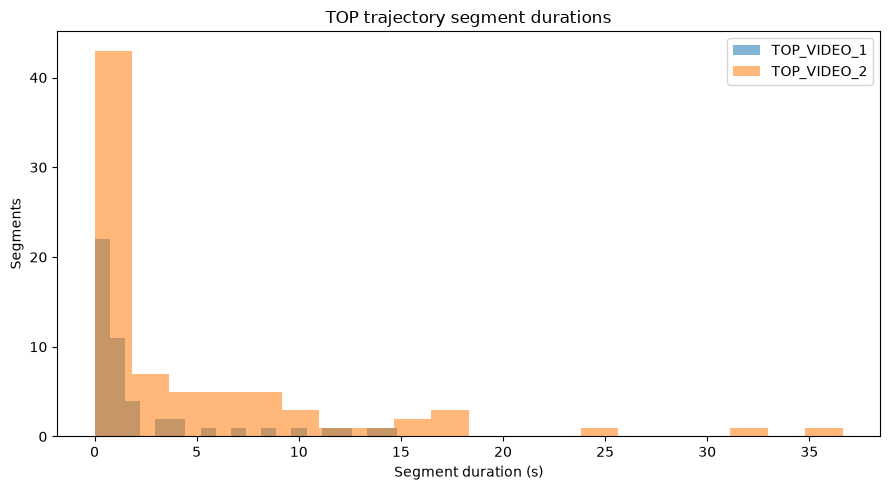

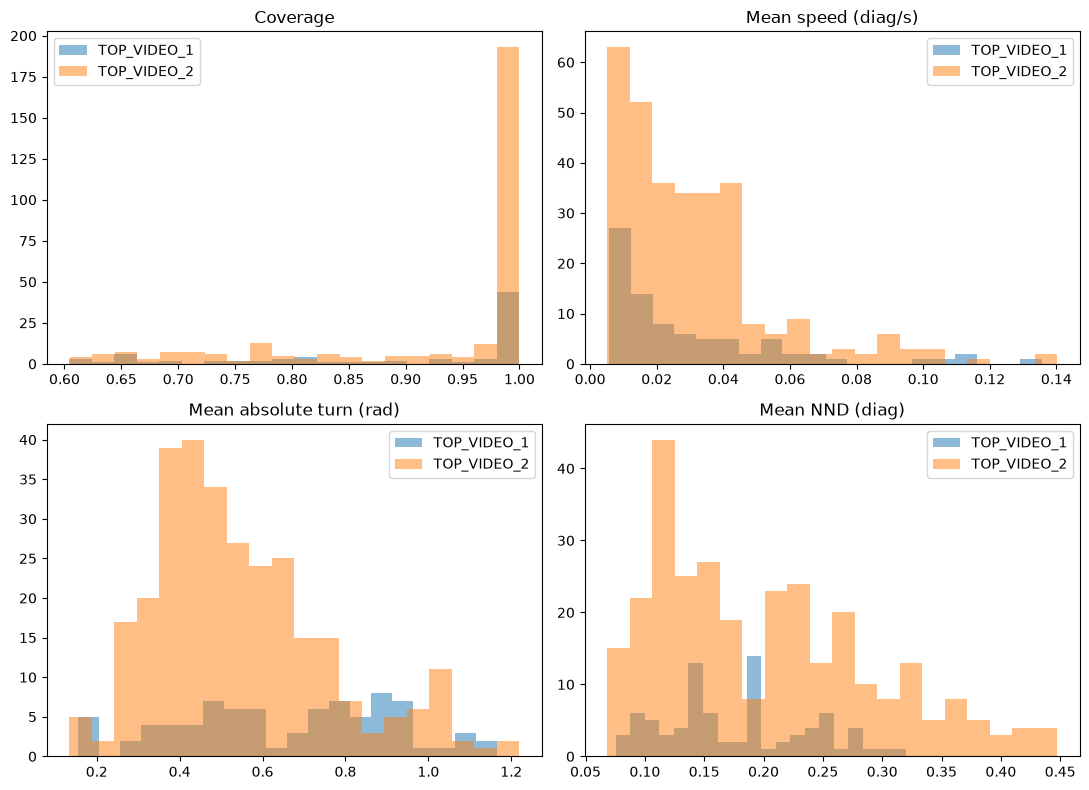

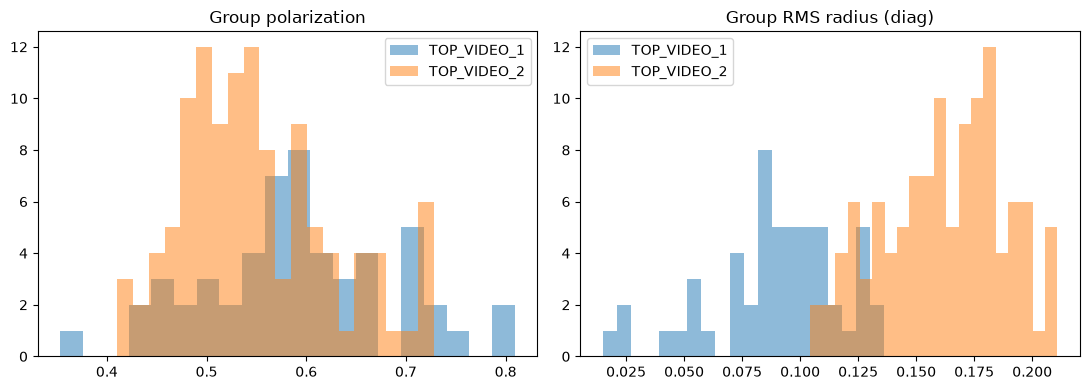

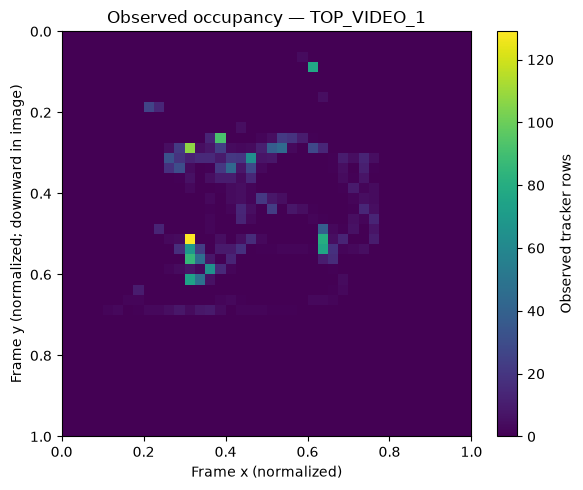

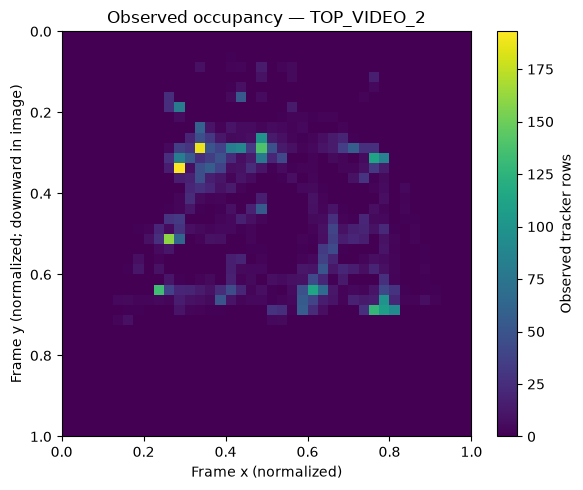

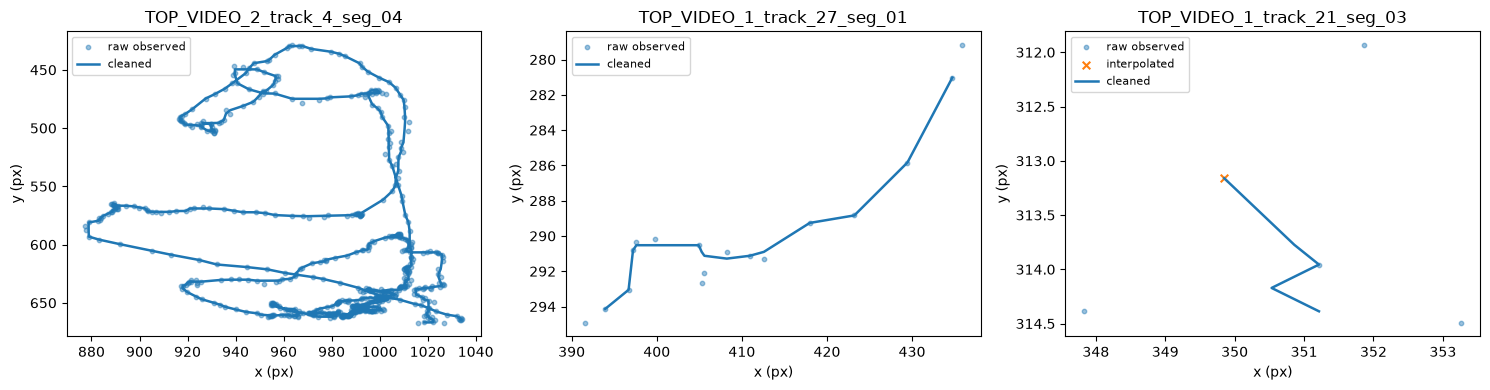

VISUAL QC PLOTS CREATED
results/behavior/plots/top_trajectory_segment_durations.png 33853 bytes
results/behavior/plots/top_individual_feature_qc.png 92160 bytes
results/behavior/plots/top_group_feature_qc.png 43817 bytes
results/behavior/plots/top_representative_cleaned_trajectories.png 147494 bytes
results/behavior/plots/top_TOP_VIDEO_1_occupancy_heatmap.png 49637 bytes
results/behavior/plots/top_TOP_VIDEO_2_occupancy_heatmap.png 51297 bytes


In [12]:
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 5))
for video_id, group in SEGMENT_SUMMARY.groupby("video_id"):
    ax.hist(group["segment_duration_sec"], bins=20, alpha=0.55, label=video_id)
ax.set(xlabel="Segment duration (s)", ylabel="Segments", title="TOP trajectory segment durations")
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_PATHS[0], dpi=150)
plt.show()
plt.close(fig)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for video_id, group in INDIVIDUAL.groupby("video_id"):
    axes[0, 0].hist(group["coverage_ratio"].dropna(), bins=20, alpha=0.5, label=video_id)
    axes[0, 1].hist(group["mean_speed_diag_s"].dropna(), bins=20, alpha=0.5, label=video_id)
    axes[1, 0].hist(group["mean_abs_turn_rad"].dropna(), bins=20, alpha=0.5, label=video_id)
    axes[1, 1].hist(group["mean_nnd_diag"].dropna(), bins=20, alpha=0.5, label=video_id)
for ax, title in zip(axes.ravel(), ["Coverage", "Mean speed (diag/s)", "Mean absolute turn (rad)", "Mean NND (diag)"]):
    ax.set_title(title); ax.legend()
fig.tight_layout()
fig.savefig(PLOT_PATHS[1], dpi=150)
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for video_id, group in GROUP.groupby("video_id"):
    axes[0].hist(group["mean_group_polarization"].dropna(), bins=20, alpha=0.5, label=video_id)
    axes[1].hist(group["mean_group_rms_radius_diag"].dropna(), bins=20, alpha=0.5, label=video_id)
axes[0].set_title("Group polarization"); axes[1].set_title("Group RMS radius (diag)")
for ax in axes: ax.legend()
fig.tight_layout()
fig.savefig(PLOT_PATHS[2], dpi=150)
plt.show()
plt.close(fig)

for video_id in VIDEO_META:
    points = CLEAN.loc[CLEAN["video_id"].eq(video_id) & CLEAN["observed"]]
    fig, ax = plt.subplots(figsize=(6, 5))
    histogram = ax.hist2d(points["cx_norm_clean"], points["cy_norm_clean"], bins=40, range=[[0, 1], [0, 1]], cmap="viridis")
    fig.colorbar(histogram[3], ax=ax, label="Observed tracker rows")
    ax.set(xlim=(0, 1), ylim=(1, 0), xlabel="Frame x (normalized)", ylabel="Frame y (normalized; downward in image)", title=f"Observed occupancy — {video_id}")
    fig.tight_layout()
    path = PLOTS_DIR / f"top_{video_id}_occupancy_heatmap.png"
    fig.savefig(path, dpi=150)
    plt.show()
    plt.close(fig)

duration_order = SEGMENT_SUMMARY.sort_values("segment_duration_sec")
selected_uids = []
if len(duration_order):
    selected_uids.append(duration_order.iloc[-1]["trajectory_uid"])
    selected_uids.append(duration_order.iloc[len(duration_order) // 2]["trajectory_uid"])
with_interp = duration_order.loc[duration_order["interpolated_points"].gt(0)]
if len(with_interp):
    selected_uids.append(with_interp.iloc[0]["trajectory_uid"])
selected_uids = list(dict.fromkeys(selected_uids))

fig, axes = plt.subplots(1, max(1, len(selected_uids)), figsize=(5 * max(1, len(selected_uids)), 4), squeeze=False)
for ax, uid in zip(axes.ravel(), selected_uids):
    segment = CLEAN.loc[CLEAN["trajectory_uid"].eq(uid)].sort_values("frame_index")
    observed = segment.loc[segment["observed"]]
    interpolated = segment.loc[segment["interpolated"]]
    ax.scatter(observed["cx_raw"], observed["cy_raw"], s=10, alpha=0.45, label="raw observed")
    if len(interpolated):
        ax.scatter(interpolated["cx_raw"], interpolated["cy_raw"], s=30, marker="x", label="interpolated")
    ax.plot(segment["cx_clean"], segment["cy_clean"], linewidth=1.8, label="cleaned")
    ax.invert_yaxis(); ax.set_title(uid); ax.set_xlabel("x (px)"); ax.set_ylabel("y (px)"); ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(PLOT_PATHS[3], dpi=150)
plt.show()
plt.close(fig)

print("VISUAL QC PLOTS CREATED")
for path in PLOT_PATHS:
    print(path.relative_to(PROJECT_ROOT), path.stat().st_size, "bytes")


## 13. Machine-readable feature schema

Every output field is documented by name, level, unit, definition, source, missingness rule, and scientific caution. Repeated names at different levels are separate schema entries.


In [13]:
IDENTIFIER_COLUMNS = {
    "camera": ("category", "Camera view; fixed to top.", "Notebook configuration"),
    "experimental_context": ("category", "Experimental condition metadata; UNKNOWN in this checkpoint.", "Notebook configuration"),
    "video_id": ("category", "Stable video identifier from Notebook 14.", "Notebook 14 tracking output"),
    "source_video": ("category", "Source video filename.", "Notebook 14 tracking output"),
    "window_id": ("category", "Unique individual-window key.", "Notebook 15"),
    "group_window_id": ("category", "Unique group-window key.", "Notebook 15"),
    "trajectory_uid": ("category", "Video-local same-track same-segment key.", "Notebook 15 segmentation"),
    "track_id": ("tracker_id", "Video-local ByteTrack identifier.", "Notebook 14 tracking output"),
    "frame_index": ("frame", "Zero-based source frame index.", "Notebook 14 tracking output"),
    "time_sec": ("seconds", "Frame time derived from frame index and source FPS.", "Notebook 15"),
    "window_start_sec": ("seconds", "Inclusive global window start time.", "Notebook 15 global grid"),
    "window_end_sec": ("seconds", "Exclusive global window end time.", "Notebook 15 global grid"),
    "window_mid_sec": ("seconds", "Midpoint of the global time window.", "Notebook 15 global grid"),
    "fps_source": ("frames/s", "Source video frame rate.", "Video metadata verified against Notebook 14"),
}

QUALITY_DEFINITIONS = {
    "n_points": ("count", "Cleaned trajectory points within an individual window."),
    "coverage_ratio": ("ratio", "Cleaned points divided by expected source frames in the global window."),
    "observed_ratio": ("ratio", "Fraction of individual-window rows directly observed by the tracker."),
    "interpolated_ratio": ("ratio", "Fraction of individual-window rows inserted by short-gap interpolation."),
    "window_time_span_sec": ("seconds", "Elapsed time between first and last retained point in the window."),
    "mean_detection_confidence": ("ratio", "Mean detector confidence over observed rows only."),
    "expected_frames": ("count", "Number of source frames in the global half-open window."),
    "frames_with_any_track": ("count", "Frames with at least one observed active tracker row."),
    "group_frame_coverage": ("ratio", "Frames with any observed track divided by expected frames."),
    "frames_with_2plus_tracks": ("count", "Frames with at least two observed active tracker rows."),
    "social_metric_frame_ratio": ("ratio", "Frames supporting pairwise geometry divided by expected frames."),
    "polarization_valid_frame_ratio": ("ratio", "Frames with valid group polarization divided by expected frames."),
    "n_valid_headings": ("count", "Observed active tracks with a valid non-zero within-segment heading."),
}

FEATURE_DEFINITIONS = {
    "path_length_px": ("px", "Sum of within-window cleaned step distances."),
    "path_length_diag": ("diag", "Path length divided by image diagonal."),
    "distance_last_1s_px": ("px", "Cleaned path length during the final one second of the window."),
    "distance_last_1s_diag": ("diag", "Final-one-second path length divided by image diagonal."),
    "net_displacement_px": ("px", "Distance between first and last cleaned point in the window."),
    "net_displacement_diag": ("diag", "Net displacement divided by image diagonal."),
    "path_efficiency": ("ratio", "Net displacement divided by path length."),
    "mean_speed_px_s": ("px/s", "Mean cleaned step speed."),
    "median_speed_px_s": ("px/s", "Median cleaned step speed."),
    "max_speed_px_s": ("px/s", "Maximum cleaned step speed."),
    "p95_speed_px_s": ("px/s", "95th percentile cleaned step speed."),
    "speed_std_px_s": ("px/s", "Population standard deviation of cleaned step speed."),
    "mean_speed_diag_s": ("diag/s", "Mean speed normalized by image diagonal."),
    "median_speed_diag_s": ("diag/s", "Median speed normalized by image diagonal."),
    "max_speed_diag_s": ("diag/s", "Maximum speed normalized by image diagonal."),
    "mean_abs_accel_px_s2": ("px/s^2", "Mean absolute finite-difference acceleration."),
    "p95_abs_accel_px_s2": ("px/s^2", "95th percentile absolute finite-difference acceleration."),
    "mean_abs_accel_diag_s2": ("diag/s^2", "Mean absolute acceleration normalized by image diagonal."),
    "mean_abs_turn_rad": ("rad", "Mean absolute wrapped change between successive valid headings."),
    "median_abs_turn_rad": ("rad", "Median absolute wrapped heading change."),
    "p95_abs_turn_rad": ("rad", "95th percentile absolute wrapped heading change."),
    "cumulative_abs_turn_rad": ("rad", "Sum of absolute wrapped heading changes."),
    "turn_rate_rad_s": ("rad/s", "Cumulative absolute turn divided by observed window time span."),
    "heading_resultant_length": ("ratio", "Magnitude of the mean within-trajectory heading unit vector."),
    "x_mean_norm": ("ratio", "Mean cleaned x coordinate divided by frame width."),
    "x_std_norm": ("ratio", "Population standard deviation of normalized x."),
    "x_range_norm": ("ratio", "Range of normalized x."),
    "y_mean_norm": ("ratio", "Mean cleaned y coordinate divided by frame height."),
    "y_std_norm": ("ratio", "Population standard deviation of normalized y."),
    "y_range_norm": ("ratio", "Range of normalized y."),
    "mean_distance_to_frame_center_diag": ("diag", "Mean distance to image-frame center divided by image diagonal."),
    "median_distance_to_frame_center_diag": ("diag", "Median distance to image-frame center divided by image diagonal."),
    "mean_distance_to_nearest_frame_edge_min_dim": ("ratio", "Mean nearest image-edge distance divided by minimum frame dimension."),
    "median_distance_to_nearest_frame_edge_min_dim": ("ratio", "Median nearest image-edge distance divided by minimum frame dimension."),
    "frame_edge_band_ratio": ("ratio", "Fraction of rows within the configured image-frame edge band."),
    "frame_center_box_ratio": ("ratio", "Fraction of rows within the configured image-frame center box."),
    "nearest_neighbor_distance_px": ("px", "Distance to nearest other observed active track in the same frame."),
    "nearest_neighbor_distance_diag": ("diag", "Nearest-neighbor distance divided by image diagonal."),
    "mean_nnd_diag": ("diag", "Mean valid nearest-neighbor distance at the stated level."),
    "median_nnd_diag": ("diag", "Median valid nearest-neighbor distance at the stated level."),
    "min_nnd_diag": ("diag", "Minimum valid nearest-neighbor distance in an individual window."),
    "neighbor_observation_ratio": ("ratio", "Observed individual rows with a valid neighbor divided by observed individual rows."),
    "n_active_tracks": ("count", "Observed active tracker rows in a frame."),
    "group_centroid_x_norm": ("ratio", "Mean observed-track x coordinate divided by frame width."),
    "group_centroid_y_norm": ("ratio", "Mean observed-track y coordinate divided by frame height."),
    "mean_pairwise_distance_diag": ("diag", "Mean unique-pair distance normalized by image diagonal."),
    "median_pairwise_distance_diag": ("diag", "Median unique-pair distance normalized by image diagonal."),
    "min_pairwise_distance_diag": ("diag", "Minimum unique-pair distance normalized by image diagonal."),
    "max_pairwise_distance_diag": ("diag", "Maximum unique-pair distance normalized by image diagonal."),
    "group_rms_radius_diag": ("diag", "RMS distance to observed group centroid divided by image diagonal."),
    "group_bbox_area_ratio": ("ratio", "Observed-track bounding rectangle area divided by frame area."),
    "group_convex_hull_area_ratio": ("ratio", "Observed-track convex-hull area divided by frame area."),
    "group_polarization": ("ratio", "Magnitude of mean valid observed-track heading unit vectors."),
    "mean_active_tracks": ("count", "Mean observed active tracker rows across all window frames."),
    "median_active_tracks": ("count", "Median observed active tracker rows across all window frames."),
    "min_active_tracks": ("count", "Minimum observed active tracker rows across all window frames."),
    "max_active_tracks": ("count", "Maximum observed active tracker rows across all window frames."),
    "mean_group_centroid_x_norm": ("ratio", "Window mean of valid frame group-centroid x."),
    "mean_group_centroid_y_norm": ("ratio", "Window mean of valid frame group-centroid y."),
    "mean_group_rms_radius_diag": ("diag", "Window mean of valid frame group RMS radius."),
    "median_group_rms_radius_diag": ("diag", "Window median of valid frame group RMS radius."),
    "mean_group_bbox_area_ratio": ("ratio", "Window mean of frame group bounding-area ratio."),
    "mean_group_convex_hull_area_ratio": ("ratio", "Window mean of valid frame convex-hull area ratio."),
    "mean_group_polarization": ("ratio", "Window mean of valid frame polarization."),
    "median_group_polarization": ("ratio", "Window median of valid frame polarization."),
}

def schema_entry(name, level):
    if name in IDENTIFIER_COLUMNS:
        unit, definition, source = IDENTIFIER_COLUMNS[name]
        missingness = "Required; never missing in emitted rows."
        caution = "Identifier/metadata only; it is not a biological label."
    elif name in QUALITY_DEFINITIONS:
        unit, definition = QUALITY_DEFINITIONS[name]
        source = "Notebook 15 quality accounting"
        missingness = "Required unless its denominator is mathematically unavailable."
        caution = "Quality/coverage describes tracker-derived evidence, not biological certainty."
    else:
        unit, definition = FEATURE_DEFINITIONS[name]
        source = "Cleaned within-segment trajectory" if level == "individual_window" else "Observed-only group geometry"
        if any(token in name for token in ["nnd", "pairwise", "polarization"]):
            missingness = "NaN when the required neighbor count or valid headings are unavailable."
        elif "convex_hull" in name:
            missingness = "NaN when fewer than three observed active tracks are present."
        elif name in {"path_efficiency", "turn_rate_rad_s", "heading_resultant_length"}:
            missingness = "NaN when the mathematical denominator or valid movement sequence is unavailable."
        else:
            missingness = "NaN when no valid source value exists at this level."
        caution = (
            "Same-track same-segment descriptor; tracker ID is not biological identity."
            if level == "individual_window"
            else "Instantaneous tracker-observed group descriptor; active tracks are not a verified fish count."
        )
    if any(token in name for token in ["frame_edge", "frame_center", "frame_center", "frame_edge"]):
        caution += " Image-frame geometry is not calibrated tank geometry."
    return {
        "name": name,
        "level": level,
        "unit": unit,
        "definition": definition,
        "source": source,
        "missingness_rule": missingness,
        "scientific_caution": caution,
    }

individual_quality = [
    "n_points", "coverage_ratio", "observed_ratio", "interpolated_ratio",
    "window_time_span_sec", "mean_detection_confidence",
]
group_quality = [
    "expected_frames", "frames_with_any_track", "group_frame_coverage",
    "frames_with_2plus_tracks", "social_metric_frame_ratio", "polarization_valid_frame_ratio",
]

SCHEMA_ENTRIES = []
for column in INDIVIDUAL.columns:
    level = "identifier" if column in IDENTIFIER_COLUMNS else ("quality" if column in individual_quality else "individual_window")
    SCHEMA_ENTRIES.append(schema_entry(column, level))
for column in GROUP_FRAME.columns:
    level = "identifier" if column in IDENTIFIER_COLUMNS else ("quality" if column == "n_valid_headings" else "group_frame")
    SCHEMA_ENTRIES.append(schema_entry(column, level))
for column in GROUP.columns:
    level = "identifier" if column in IDENTIFIER_COLUMNS else ("quality" if column in group_quality else "group_window")
    SCHEMA_ENTRIES.append(schema_entry(column, level))

FEATURE_SCHEMA = {
    "experiment_id": FEATURE_EXPERIMENT_ID,
    "camera": CAMERA,
    "window_sec": WINDOW_SEC,
    "step_sec": STEP_SEC,
    "experimental_context": EXPERIMENTAL_CONTEXT,
    "arena_geometry": ARENA_GEOMETRY,
    "wall_metrics_available": ARENA_GEOMETRY is not None,
    "biological_identity_established": False,
    "features": SCHEMA_ENTRIES,
}
assert all(set(entry) == {"name", "level", "unit", "definition", "source", "missingness_rule", "scientific_caution"} for entry in SCHEMA_ENTRIES)
print("FEATURE SCHEMA ENTRIES:", len(SCHEMA_ENTRIES))
display(pd.DataFrame(SCHEMA_ENTRIES).head(20))


FEATURE SCHEMA ENTRIES: 107


,name,level,unit,definition,source,missingness_rule,scientific_caution
0,camera,identifier,category,Camera view; fixed to top.,Notebook configuration,Required; never missing in emitted rows.,Identifier/metadata only; it is not a biologic...
1,experimental_context,identifier,category,Experimental condition metadata; UNKNOWN in th...,Notebook configuration,Required; never missing in emitted rows.,Identifier/metadata only; it is not a biologic...
2,video_id,identifier,category,Stable video identifier from Notebook 14.,Notebook 14 tracking output,Required; never missing in emitted rows.,Identifier/metadata only; it is not a biologic...
3,source_video,identifier,category,Source video filename.,Notebook 14 tracking output,Required; never missing in emitted rows.,Identifier/metadata only; it is not a biologic...
4,window_id,identifier,category,Unique individual-window key.,Notebook 15,Required; never missing in emitted rows.,Identifier/metadata only; it is not a biologic...
5,trajectory_uid,identifier,category,Video-local same-track same-segment key.,Notebook 15 segmentation,Required; never missing in emitted rows.,Identifier/metadata only; it is not a biologic...
6,track_id,identifier,tracker_id,Video-local ByteTrack identifier.,Notebook 14 tracking output,Required; never missing in emitted rows.,Identifier/metadata only; it is not a biologic...
7,window_start_sec,identifier,seconds,Inclusive global window start time.,Notebook 15 global grid,Required; never missing in emitted rows.,Identifier/metadata only; it is not a biologic...
8,window_end_sec,identifier,seconds,Exclusive global window end time.,Notebook 15 global grid,Required; never missing in emitted rows.,Identifier/metadata only; it is not a biologic...
9,window_mid_sec,identifier,seconds,Midpoint of the global time window.,Notebook 15 global grid,Required; never missing in emitted rows.,Identifier/metadata only; it is not a biologic...


## 14. Evidence and output export

Full analytical tables are written under ignored `outputs/`. Parquet is used only when an existing engine is available; otherwise CSV is used without installing a dependency. Small summaries, schema, logs, and QC plots are written to committable evidence paths.


In [14]:
for directory in [
    OUTPUT_TRAJECTORY_DIR, OUTPUT_BEHAVIOR_DIR, RESULTS_TRAJECTORY_DIR,
    RESULTS_BEHAVIOR_DIR, PLOTS_DIR, TRAJECTORY_LOG_DIR, BEHAVIOR_LOG_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

def write_full_table(table, parquet_path, csv_path):
    if importlib.util.find_spec("pyarrow") is not None:
        table.to_parquet(parquet_path, index=False, engine="pyarrow")
        return parquet_path, "parquet"
    if importlib.util.find_spec("fastparquet") is not None:
        table.to_parquet(parquet_path, index=False, engine="fastparquet")
        return parquet_path, "parquet"
    table.to_csv(csv_path, index=False)
    return csv_path, "csv_fallback"

CLEAN_OUTPUT_COLUMNS = [
    "camera", "experimental_context", "video_id", "source_video", "frame_index", "time_sec",
    "track_id", "trajectory_segment_no", "trajectory_uid", "segment_eligible_individual",
    "observed", "interpolated", "confidence", "x1", "y1", "x2", "y2", "cx_raw", "cy_raw",
    "cx_clean", "cy_clean", "cx_norm_clean", "cy_norm_clean", "frame_width", "frame_height",
    "image_diagonal_px", "fps_source", "segment_n_points", "segment_observed_points",
    "segment_start_sec", "segment_end_sec", "segment_duration_sec", "segment_observed_ratio",
    "segment_interpolated_ratio", "dt_sec", "dx_px", "dy_px", "step_distance_px",
    "step_distance_diag", "speed_px_s", "speed_diag_s", "heading_rad", "turn_rad",
    "abs_accel_px_s2", "abs_accel_diag_s2", "distance_to_frame_center_diag",
    "distance_to_nearest_frame_edge_min_dim", "in_frame_edge_band", "in_frame_center_box",
    "nearest_neighbor_distance_px", "nearest_neighbor_distance_diag", "wall_metrics_available",
]

trajectory_output, trajectory_format = write_full_table(CLEAN[CLEAN_OUTPUT_COLUMNS], TRAJECTORY_PARQUET, TRAJECTORY_CSV)
individual_output, individual_format = write_full_table(INDIVIDUAL, INDIVIDUAL_PARQUET, INDIVIDUAL_CSV)
group_output, group_format = write_full_table(GROUP, GROUP_PARQUET, GROUP_CSV)

trajectory_summary_rows = []
for stats in RAW_FILE_STATS:
    video_id = stats["video_id"]
    segment_rows = SEGMENT_SUMMARY.loc[SEGMENT_SUMMARY["video_id"].eq(video_id)]
    clean_rows = CLEAN.loc[CLEAN["video_id"].eq(video_id)]
    gap_rows = TRACK_GAP_AUDIT.loc[TRACK_GAP_AUDIT["video_id"].eq(video_id)]
    trajectory_summary_rows.append({
        **stats,
        "gap_events": int(gap_rows["gap_events"].sum()),
        "interpolated_gap_count": int(gap_rows["interpolated_gap_count"].sum()),
        "interpolated_rows": int(clean_rows["interpolated"].sum()),
        "segments_created": int(len(segment_rows)),
        "segments_discarded_from_individual_analysis": int((~segment_rows["segment_eligible_individual"]).sum()),
        "cleaned_rows": int(len(clean_rows)),
        "median_segment_duration_sec": float(segment_rows["segment_duration_sec"].median()),
        "p95_segment_duration_sec": float(segment_rows["segment_duration_sec"].quantile(0.95)),
        "max_segment_duration_sec": float(segment_rows["segment_duration_sec"].max()),
        "segments_ge_5s": int(segment_rows["segment_duration_sec"].ge(5.0).sum()),
        "decision": "PASS_WITH_WARNING",
        "warning": "Tracker identity fragmentation remains; trajectory_uid is not biological identity.",
    })
TRAJECTORY_SUMMARY = pd.DataFrame(trajectory_summary_rows)

feature_summary_rows = []
group_summary_rows = []
for video_id, meta in VIDEO_META.items():
    stats = next(row for row in RAW_FILE_STATS if row["video_id"] == video_id)
    segment_rows = SEGMENT_SUMMARY.loc[SEGMENT_SUMMARY["video_id"].eq(video_id)]
    clean_rows = CLEAN.loc[CLEAN["video_id"].eq(video_id)]
    individual = INDIVIDUAL.loc[INDIVIDUAL["video_id"].eq(video_id)]
    group = GROUP.loc[GROUP["video_id"].eq(video_id)]
    feature_summary_rows.append({
        "video_id": video_id,
        "source_video": meta["source_video"],
        "raw_tracking_rows": stats["raw_tracking_rows"],
        "unique_raw_track_ids": stats["unique_raw_track_ids"],
        "trajectory_segments": int(len(segment_rows)),
        "cleaned_rows": int(len(clean_rows)),
        "observed_rows": int(clean_rows["observed"].sum()),
        "interpolated_rows": int(clean_rows["interpolated"].sum()),
        "segments_ge_5s": int(segment_rows["segment_duration_sec"].ge(5).sum()),
        "individual_windows": int(len(individual)),
        "median_individual_coverage": float(individual["coverage_ratio"].median()),
        "median_mean_speed_diag_s": float(individual["mean_speed_diag_s"].median()),
        "median_path_efficiency": float(individual["path_efficiency"].median()),
        "median_mean_abs_turn_rad": float(individual["mean_abs_turn_rad"].median()),
        "median_mean_nnd_diag": float(individual["mean_nnd_diag"].median()),
        "group_windows": int(len(group)),
        "median_active_tracks": float(group["median_active_tracks"].median()),
        "median_group_nnd_diag": float(group["median_nnd_diag"].median()),
        "median_group_pairwise_distance_diag": float(group["median_pairwise_distance_diag"].median()),
        "median_group_rms_radius_diag": float(group["median_group_rms_radius_diag"].median()),
        "median_group_polarization": float(group["median_group_polarization"].median()),
        "warnings": "Identity fragmentation; active tracks are not fish count; frame geometry is not tank geometry.",
    })
    group_summary_rows.append({
        "video_id": video_id,
        "source_video": meta["source_video"],
        "group_windows": int(len(group)),
        "median_group_frame_coverage": float(group["group_frame_coverage"].median()),
        "median_active_tracks": float(group["median_active_tracks"].median()),
        "median_nnd_diag": float(group["median_nnd_diag"].median()),
        "median_pairwise_distance_diag": float(group["median_pairwise_distance_diag"].median()),
        "median_group_rms_radius_diag": float(group["median_group_rms_radius_diag"].median()),
        "median_group_bbox_area_ratio": float(group["mean_group_bbox_area_ratio"].median()),
        "median_group_convex_hull_area_ratio": float(group["mean_group_convex_hull_area_ratio"].median()),
        "median_group_polarization": float(group["median_group_polarization"].median()),
        "median_social_metric_frame_ratio": float(group["social_metric_frame_ratio"].median()),
        "observed_rows_only": True,
        "decision": "PASS_WITH_WARNING",
    })

FEATURE_SUMMARY = pd.DataFrame(feature_summary_rows)
GROUP_SUMMARY = pd.DataFrame(group_summary_rows)
TRAJECTORY_SUMMARY.to_csv(TRAJECTORY_SUMMARY_PATH, index=False)
SEGMENT_SUMMARY.to_csv(SEGMENT_SUMMARY_PATH, index=False)
FEATURE_SUMMARY.to_csv(FEATURE_SUMMARY_PATH, index=False)
FEATURE_QC.to_csv(FEATURE_QC_PATH, index=False)
GROUP_SUMMARY.to_csv(GROUP_SUMMARY_PATH, index=False)
FEATURE_SCHEMA_PATH.write_text(json.dumps(json_ready(FEATURE_SCHEMA), indent=2, ensure_ascii=False) + "\n", encoding="utf-8")

ENVIRONMENT_LINES = [
    f"datetime_utc={NOTEBOOK_STARTED_AT.isoformat()}",
    f"git_commit={GIT_COMMIT}",
    f"python_executable={sys.executable}",
    f"python={platform.python_version()}",
    f"conda_env={CONDA_ENV}",
    f"pandas={pd.__version__}",
    f"numpy={np.__version__}",
    f"opencv={cv2.__version__}",
    f"matplotlib={matplotlib.__version__}",
    f"torch={TORCH_VERSION}",
    f"cuda_available={CUDA_AVAILABLE}",
    f"gpu={GPU_NAME}",
]
(TRAJECTORY_LOG_DIR / "config.yaml").write_text(yaml.safe_dump({
    "experiment_id": TRAJECTORY_EXPERIMENT_ID,
    "n14_tracking_experiment_id": N14_TRACKING_EXPERIMENT_ID,
    "raw_inputs": CONFIG["videos"],
    "tracker_config": str(TRACKER_CONFIG_PATH.relative_to(PROJECT_ROOT)),
    "tracker_config_sha256": TRACKER_CONFIG_SHA256,
    "max_interp_gap_frames": MAX_INTERP_GAP_FRAMES,
    "smooth_window_frames": SMOOTH_WINDOW_FRAMES,
    "min_segment_points": MIN_SEGMENT_POINTS,
    "cross_id_stitching": False,
}, sort_keys=False), encoding="utf-8")
(BEHAVIOR_LOG_DIR / "config.yaml").write_text(yaml.safe_dump({
    "experiment_id": FEATURE_EXPERIMENT_ID,
    "trajectory_experiment_id": TRAJECTORY_EXPERIMENT_ID,
    "window_sec": WINDOW_SEC,
    "step_sec": STEP_SEC,
    "min_window_coverage": MIN_WINDOW_COVERAGE,
    "primary_group_rows": "observed_only",
    "arena_geometry": ARENA_GEOMETRY,
    "wall_metrics_available": False,
    "physical_calibration_available": False,
    "experimental_context": EXPERIMENTAL_CONTEXT,
}, sort_keys=False), encoding="utf-8")
for log_dir in (TRAJECTORY_LOG_DIR, BEHAVIOR_LOG_DIR):
    (log_dir / "environment.txt").write_text("\n".join(ENVIRONMENT_LINES) + "\n", encoding="utf-8")

TRAJECTORY_OUTPUT_SHA256 = sha256_file(trajectory_output)
INDIVIDUAL_OUTPUT_SHA256 = sha256_file(individual_output)
GROUP_OUTPUT_SHA256 = sha256_file(group_output)
COMMON_WARNINGS = [
    "Notebook 14 has substantial identity fragmentation; track IDs and trajectory UIDs are not biological identity.",
    "Primary group metrics use observed tracker rows only; n_active_tracks is not a verified fish count.",
    "Official TOP identity ground truth is unavailable; no HOTA or IDF1 is reported.",
    "Arena geometry and physical scale are unavailable; spatial features are frame-relative.",
    "T1/T2 cannot be inferred; experimental_context remains UNKNOWN.",
    "Acceleration can amplify residual tracker noise; outliers are flagged descriptively and not automatically deleted.",
]

trajectory_log_summary = {
    "experiment_id": TRAJECTORY_EXPERIMENT_ID,
    "datetime_utc": NOTEBOOK_STARTED_AT.isoformat(),
    "git_commit": GIT_COMMIT,
    "n14_experiment_id": N14_TRACKING_EXPERIMENT_ID,
    "input_raw_tracking_paths": [str(spec["raw_path"].relative_to(PROJECT_ROOT)) for spec in VIDEO_SPECS],
    "input_raw_tracking_sha256": RAW_SHA256,
    "tracker_config": str(TRACKER_CONFIG_PATH.relative_to(PROJECT_ROOT)),
    "tracker_config_sha256": TRACKER_CONFIG_SHA256,
    "cleaning_config": {
        "max_interp_gap_frames": MAX_INTERP_GAP_FRAMES,
        "smooth_window_frames": SMOOTH_WINDOW_FRAMES,
        "min_segment_points": MIN_SEGMENT_POINTS,
        "cross_id_stitching": False,
    },
    "output_path": str(trajectory_output.relative_to(PROJECT_ROOT)),
    "output_format": trajectory_format,
    "output_sha256": TRAJECTORY_OUTPUT_SHA256,
    "per_video_qc": TRAJECTORY_SUMMARY.to_dict(orient="records"),
    "warnings": COMMON_WARNINGS,
    "decision": "PASS_WITH_WARNING",
}
behavior_log_summary = {
    "experiment_id": FEATURE_EXPERIMENT_ID,
    "datetime_utc": NOTEBOOK_STARTED_AT.isoformat(),
    "git_commit": GIT_COMMIT,
    "input_cleaned_trajectory_path": str(trajectory_output.relative_to(PROJECT_ROOT)),
    "input_cleaned_trajectory_sha256": TRAJECTORY_OUTPUT_SHA256,
    "window_sec": WINDOW_SEC,
    "step_sec": STEP_SEC,
    "coverage_threshold": MIN_WINDOW_COVERAGE,
    "feature_groups": ["movement", "turning", "frame_relative_spatial", "nearest_neighbor", "instantaneous_group_geometry", "group_polarization"],
    "output_paths": {
        "individual": str(individual_output.relative_to(PROJECT_ROOT)),
        "group": str(group_output.relative_to(PROJECT_ROOT)),
        "schema": str(FEATURE_SCHEMA_PATH.relative_to(PROJECT_ROOT)),
    },
    "output_sha256": {
        "individual": INDIVIDUAL_OUTPUT_SHA256,
        "group": GROUP_OUTPUT_SHA256,
        "schema": sha256_file(FEATURE_SCHEMA_PATH),
    },
    "row_counts": {
        "individual_windows": int(len(INDIVIDUAL)),
        "group_windows": int(len(GROUP)),
        "group_frames": int(len(GROUP_FRAME)),
    },
    "per_video_summary": FEATURE_SUMMARY.to_dict(orient="records"),
    "nan_summary": FEATURE_QC[["table", "feature", "nan_rate"]].to_dict(orient="records"),
    "warnings": COMMON_WARNINGS,
    "decision": "PASS_WITH_WARNING",
    "next_step": "STOP for user review; Notebook 16 sensor synchronization requires explicit approval.",
}
(TRAJECTORY_LOG_DIR / "summary.json").write_text(json.dumps(json_ready(trajectory_log_summary), indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
(BEHAVIOR_LOG_DIR / "summary.json").write_text(json.dumps(json_ready(behavior_log_summary), indent=2, ensure_ascii=False) + "\n", encoding="utf-8")

OUTPUT_FILES = [
    trajectory_output, individual_output, group_output,
    TRAJECTORY_SUMMARY_PATH, SEGMENT_SUMMARY_PATH, FEATURE_SUMMARY_PATH,
    FEATURE_QC_PATH, GROUP_SUMMARY_PATH, FEATURE_SCHEMA_PATH,
    TRAJECTORY_LOG_DIR / "config.yaml", TRAJECTORY_LOG_DIR / "environment.txt", TRAJECTORY_LOG_DIR / "summary.json",
    BEHAVIOR_LOG_DIR / "config.yaml", BEHAVIOR_LOG_DIR / "environment.txt", BEHAVIOR_LOG_DIR / "summary.json",
    *PLOT_PATHS,
]

print("EVIDENCE EXPORT: PASS")
print(f"Full trajectory: {trajectory_output.relative_to(PROJECT_ROOT)} | rows={len(CLEAN)} | sha256={TRAJECTORY_OUTPUT_SHA256}")
print(f"Individual features: {individual_output.relative_to(PROJECT_ROOT)} | rows={len(INDIVIDUAL)} | sha256={INDIVIDUAL_OUTPUT_SHA256}")
print(f"Group features: {group_output.relative_to(PROJECT_ROOT)} | rows={len(GROUP)} | sha256={GROUP_OUTPUT_SHA256}")
for path in OUTPUT_FILES:
    print(f"Created {path.relative_to(PROJECT_ROOT)} | size={path.stat().st_size} bytes")
display(FEATURE_SUMMARY)
display(GROUP_SUMMARY)


EVIDENCE EXPORT: PASS
Full trajectory: outputs/top/trajectory/top_cleaned_trajectories.csv | rows=8819 | sha256=9b10268eee589decbbe2a2010ced8f721311ed99c0704051aaf3bfa740fb1225
Individual features: outputs/top/behavior/top_individual_window_features.csv | rows=382 | sha256=2a6a3396a41de3c5ac78b4a1391aa2c11858a8cfde53633a18bbb1a10cb4faa7
Group features: outputs/top/behavior/top_group_window_features.csv | rows=167 | sha256=ba5a2687d6c3b998f03a2b060c6084925de83537f186f0e4a7b54fec2d04c893
Created outputs/top/trajectory/top_cleaned_trajectories.csv | size=6282058 bytes
Created outputs/top/behavior/top_individual_window_features.csv | size=356363 bytes
Created outputs/top/behavior/top_group_window_features.csv | size=63267 bytes
Created results/trajectory/top_trajectory_cleaning_summary.csv | size=798 bytes
Created results/trajectory/top_trajectory_segment_summary.csv | size=19790 bytes
Created results/behavior/top_feature_summary.csv | size=1064 bytes
Created results/behavior/top_feature_q

,video_id,source_video,raw_tracking_rows,unique_raw_track_ids,trajectory_segments,cleaned_rows,observed_rows,interpolated_rows,segments_ge_5s,individual_windows,...,median_path_efficiency,median_mean_abs_turn_rad,median_mean_nnd_diag,group_windows,median_active_tracks,median_group_nnd_diag,median_group_pairwise_distance_diag,median_group_rms_radius_diag,median_group_polarization,warnings
0,TOP_VIDEO_1,1.mp4,2424,33,49,2455,2417,38,8,82,...,0.510007,0.687178,0.163246,53,2.0,0.191577,0.202716,0.096187,0.626676,Identity fragmentation; active tracks are not ...
1,TOP_VIDEO_2,2.mp4,6330,53,78,6364,6329,35,26,300,...,0.483203,0.502675,0.179552,114,3.0,0.166098,0.277616,0.165846,0.504082,Identity fragmentation; active tracks are not ...


,video_id,source_video,group_windows,median_group_frame_coverage,median_active_tracks,median_nnd_diag,median_pairwise_distance_diag,median_group_rms_radius_diag,median_group_bbox_area_ratio,median_group_convex_hull_area_ratio,median_group_polarization,median_social_metric_frame_ratio,observed_rows_only,decision
0,TOP_VIDEO_1,1.mp4,53,1.0,2.0,0.191577,0.202716,0.096187,0.043250,0.025219,0.626676,0.876289,True,PASS_WITH_WARNING
1,TOP_VIDEO_2,2.mp4,114,1.0,3.0,0.166098,0.277616,0.165846,0.129095,0.061652,0.504082,1.000000,True,PASS_WITH_WARNING


## 15. Scientific interpretation and limitations

Allowed interpretation is comparative and descriptive: higher/lower frame-relative speed, turning, proximity, polarization, dispersion, or image-frame occupancy.

Not established in this checkpoint:

- stable biological identity, cross-video identity, FRONT↔TOP identity, stable dyads, or social networks;
- verified fish count or official MOT identity accuracy;
- tank-wall distance, physical distance/speed, T1/T2 mapping, or sensor alignment;
- feeding, stress, sickness, anxiety, aggression, or any other biological/health label.

Identity fragmentation remains inherited from Notebook 14. It is handled by same-ID same-segment calculations and explicit missingness, not by heuristic stitching.


## 16. Final decision and next step

The final cell reports the analytical checkpoint. Notebook 16 is only a proposed next step and is not started here.


In [15]:
NOTEBOOK_RUNTIME_SEC = time.perf_counter() - NOTEBOOK_START_TIME
FINAL_DECISION = {
    "status": "PASS_WITH_WARNING",
    "runtime_sec": round(NOTEBOOK_RUNTIME_SEC, 3),
    "top_trajectory_cleaning": "PASS_WITH_WARNING",
    "top_individual_features": "PASS_WITH_WARNING",
    "top_group_features": "PASS_WITH_WARNING",
    "geometry_calibration": "NOT_AVAILABLE",
    "biological_identity": "NOT_ESTABLISHED",
    "trajectory_rows": int(len(CLEAN)),
    "trajectory_segments": int(CLEAN["trajectory_uid"].nunique()),
    "individual_windows": int(len(INDIVIDUAL)),
    "group_windows": int(len(GROUP)),
    "features_usable_for_notebook_16": True,
    "warnings": COMMON_WARNINGS,
    "output_files": [str(path.relative_to(PROJECT_ROOT)) for path in OUTPUT_FILES],
    "next_step": "STOP. User reviews Notebook 15 evidence before checkpoint/Notebook 16 approval.",
}
print("FINAL SUMMARY")
print(json.dumps(FINAL_DECISION, indent=2, ensure_ascii=False))
print("TOP trajectory cleaning: PASS_WITH_WARNING")
print("TOP individual features: PASS_WITH_WARNING")
print("TOP group features: PASS_WITH_WARNING")
print("Geometry calibration: NOT AVAILABLE")
print("Biological identity: NOT ESTABLISHED")
print("Features usable for Notebook 16: YES")
print("Notebook 15: PASS_WITH_WARNING")
print("STOP — do not start Notebook 16 without explicit user approval.")


FINAL SUMMARY
{
  "status": "PASS_WITH_WARNING",
  "runtime_sec": 14.849,
  "top_trajectory_cleaning": "PASS_WITH_WARNING",
  "top_individual_features": "PASS_WITH_WARNING",
  "top_group_features": "PASS_WITH_WARNING",
  "geometry_calibration": "NOT_AVAILABLE",
  "biological_identity": "NOT_ESTABLISHED",
  "trajectory_rows": 8819,
  "trajectory_segments": 127,
  "individual_windows": 382,
  "group_windows": 167,
  "features_usable_for_notebook_16": true,
  "warnings": [
    "Notebook 14 has substantial identity fragmentation; track IDs and trajectory UIDs are not biological identity.",
    "Primary group metrics use observed tracker rows only; n_active_tracks is not a verified fish count.",
    "Official TOP identity ground truth is unavailable; no HOTA or IDF1 is reported.",
    "Arena geometry and physical scale are unavailable; spatial features are frame-relative.",
    "T1/T2 cannot be inferred; experimental_context remains UNKNOWN.",
    "Acceleration can amplify residual tracker 